In [1]:
# Somewhat standard library
import gc
import math
import os
import pickle
import time
import urllib.request
from itertools import product

# Numerical and data libraries
import numpy as np
from numpy.lib.format import open_memmap
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.image as mpimg
import matplotlib.style
from matplotlib.colors import LogNorm
import seaborn as sns

# Scikit-learn
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler

# TensorFlow and Keras
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model

from scikeras.wrappers import KerasRegressor   


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\makan\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\makan\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\makan\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "C:\Users\makan\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found

In [6]:
if os.path.exists('multi_model_comparison.csv'):
    os.remove('multi_model_comparison.csv')
    print("Old CSV removed. Starting fresh.")

# So, what happens in this notebook?

Last notebook Exploratory DAS and Hypertuning on One Field ended on :

#### End of exploratory DAS and Hypertuning on One Field Notebook


Now that I have my best single field model, with decent MAPE etc compared to CAMELS paper, trained on B but its hyperparameters are representative of other fields, I can do 3 things

1. Apply it on the **multi-field problem** ie stacking all channels and training model on ALL fields. Use the single field architecture as a baseline, then I hypertune it for the multifield problem

2. **Cross field problem** for training a machine learning algortithm on one field and use it to predict the cosmological parameters on other fields

3. Another extension of the multifield which im thinking about, could do it at the end, was thinking of testing what groups of fields, when trained together may beat the multi field. **ie how much info does multifield need really??**

Best model perfomance for context


Ωm: MAE=0.012, MAPE=3.7%, RMSE=0.023, R²=0.427, r=0.692

σ8: MAE=0.025, MAPE=2.9%, RMSE=0.046, R²=0.583, r=0.851
    
    
## This notebook

### 1. Multifield performance (all 12 fields stacked as channels)

In this notebook, I will train a machine learning algorithm to predict the cosmological parameters from multiple maps (e.g. of different fields at the same time)

I shall start with the baseline from my single field analysis, where I predicted Ω𝑚, a cosmological parameter that represents the fraction of matter in the Universe and 𝜎8, a cosmological parameter that controls the smoothness of the distribution of matter in the Universe, on the Magnetic fields. 


The following fields To be included in the multifield analysis

| Field   | Prefix   |
| ----------- | ---- | 
| Gas density     | Mgas |
| Gas velocity    | Vgas | 
| Gas temperature | T |
| Gas metallicity    | Z | 
| Neutral hydrogen density    | HI | 
| Electron number density    | ne | 
| Magnetic fields   | B | 
| Magnesium over Iron   | MgFe | 
| Dark matter density  | Mcdm | 
| Dark matter velocity  | Vcdm | 
| Stellar mass density | Mstar |  
| Total matter density | Mtot | 


Also, just a reminder, I will still be working in the '1P' IllustrisTNG simulation dataset, where a single parameter is varied at a time


### 2. Single‑field baseline (trained and tested on the same field)

To assess how much cosmological information each individual field carries on its own, I train the identical CNN architecture—originally tuned on the B‑field—on **all 12 fields separately**. Each model sees only one field at a time and is evaluated on the same field. This provides a controlled baseline so that any difference in performance can be attributed solely to the information content of that field, not to variations in model capacity or training procedure.

Ideally, one could argue that maybe I should have hypertuned each model for each field but 1. no computing resources and 2. it kinda removes objectivity

### 3. Cross‑field generalisation (train on one field, test on another)

Using the 12 saved single‑field models, I evaluate each model on **every** field, not just the one it was trained on. This answers two complementary questions:
- **Teacher quality** – which fields produce models that generalise well to other, unseen fields?
- **Field predictability** – which fields are easiest to predict, regardless of what field the model was trained on?

The results are summarised in heatmaps and bar charts, revealing that dark matter fields (Mcdm, Mtot) are both excellent teachers and highly predictable targets.

### 4. Clustered multi‑field (how much information is really needed?)

Finally, I explore whether the full 12‑field stack is necessary, or if smaller, physically motivated groups of fields can achieve comparable performance. I train the same architecture on four subsets:
- Density fields (Mcdm, Mtot, ne, HI)
- Gas fields (Z, Mgas, T, Vgas)
- Velocity fields (Vgas, Vcdm)
- A mixed subset (Mcdm, Z, Vgas)

Comparing their performance to the full multi‑field model shows that most of the cosmological information is already captured by a handful of key fields.


# A quick note on the notebook flow

I realise the structure here is a bit non‑linear to say the very least

Because, I started with the multi‑field model, then trained all the single‑field models, then went back and tried to tune the multi‑field architecture, and finally compared everything.

So the flow is:

1. **Trained the multi‑field model** using the hyperparameters that worked best for the single B‑field (this is the baseline multi‑field run).
2. **Trained all 12 single‑field models** using those same hyperparameters, so I have a fair comparison of each field's individual information content.
3. **Attempted a hyperparameter search for the multi‑field model** (which turned out to be memory‑limited and gave mixed results).
4. **Cross‑field evaluation** – tested every single‑field model on every field.
5. **Subset experiments** – saw how much information is really needed.

I only spotted the awkward ordering after the notebook was written, so I'm adding this note to make it easier to follow. 

The sections are clearly labelled, and the discussion at the end ties everything together.

# ALL FUNCTIONS


Same functions as before

**For the sake of brevity I will not be justifying the functions in markdown, I already set out my rationale for them in the Exploratory DAS and Hypertuning on One Field**

## 1.  Building a model

In [2]:
def build_camels_cnn(input_shape, num_outputs, base_filters, dense_units, dropout):
    """
    Building a configurable CNN based on the CAMELS architecture.
    
    Parameters:
        input_shape (tuple): Shape of input images (height, width, channels) for multi its set this to 12(last notebook it was 2)
        num_outputs (int): Number of regression targets (2 for Ωm, σ8),
        base_filters (int): Number of filters in the first conv block (doubles each block)
        dense_units (int): Number of neurons in the fully-connected layer
        dropout (float): Dropout rate for regularization
    
    Returns:
        model (keras.Model): Compiled or uncompiled Keras model
        param_desc (dict): Dictionary of hyperparameters for logging
    """
    
    # Defining the input layer with the specified shape
    inputs = keras.Input(shape=input_shape)
    x = inputs
    
    # Block 1: 256 -> 128
    # Applying first convolutional layer with base_filters
    x = keras.layers.Conv2D(base_filters, 3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)          # Normalising activations
    x = keras.layers.LeakyReLU(alpha=0.2)(x)          # Applying LeakyReLU activation
    
    # Block 2: 128 -> 64
    # Doubling the number of filters
    x = keras.layers.Conv2D(base_filters*2, 3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(alpha=0.2)(x)
    
    # Block 3: 64 -> 32
    # Im doubling filters, again
    x = keras.layers.Conv2D(base_filters*4, 3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(alpha=0.2)(x)
    
    # Block 4: 32 -> 16
    # Continuing progressive downsampling
    x = keras.layers.Conv2D(base_filters*8, 3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(alpha=0.2)(x)
    
    # Block 5: 16 -> 8
    x = keras.layers.Conv2D(base_filters*16, 3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(alpha=0.2)(x)
    
    # Block 6: 8 -> 4
    x = keras.layers.Conv2D(base_filters*32, 3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(alpha=0.2)(x)
    
    # Final block: 4 -> 1 (kernel size = 4, valid padding)
    # Reducing spatial dimensions to 1x1 using a 4x4 kernel
    x = keras.layers.Conv2D(base_filters*64, 4, strides=1, padding='valid')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(alpha=0.2)(x)
    
    # Flattening the (1, 1, base_filters*64) tensor into a 1D vector
    x = keras.layers.Flatten()(x)
    
    # Adding a dense (fully-connected) layer for final representation
    x = keras.layers.Dense(dense_units, activation='relu')(x)
    
    # Applying dropout for regularization
    x = keras.layers.Dropout(dropout)(x)
    
    # Output layer: predicting num_outputs values (linear activation for regression)
    outputs = keras.layers.Dense(num_outputs)(x)
    
    # Creating the Keras Model object
    model = keras.Model(inputs, outputs)
    
    # Capturing hyperparameters in a dictionary for logging and comparison
    param_desc = {
        'input_shape': input_shape,
        'num_outputs': num_outputs,
        'base_filters': base_filters,
        'dense_units': dense_units,
        'dropout': dropout
    }
    
    return model, param_desc

## 2. Training Model Function

I motivated my loss functions in the Exploratory DAS and Hypertuning on One Field notebook

The training model function here is the same as in Exploratory DAS and Hypertuning on One Field notebook but with just one minor change, theres no sample_weight argument because training is done via a generator that yields batches on‑the‑fly. 

In [3]:
def train_model(model, X_train, y_train, X_val, y_val,
                lr=1e-3, patience=8, epochs=50, batch_size=16, verbose=1):
    """
    Compile and train a Keras model with early stopping.
    
    Returns:
        history: training history object
    """
    # Compiling the model with Adam optimizer and mean squared error loss
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss='mse',
                  metrics=['mae'])
    
    # Setting up early stopping to monitor validation loss
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )
    
    # Fitting the model on the training data with validation
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=verbose
    )
    return history

## 3. Get Predictions Function

In [4]:
def get_predictions(model, X_test, scaler, y_test):
    """
    Generate predictions and inverse transform to original units.
    
    Returns:
        y_true: true values in original units
        y_pred: predicted values in original units
    """
    y_pred_scaled = model.predict(X_test, verbose=1)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test)
    return y_true, y_pred

## 4.  Saving Results Functions

a) Regression report as usual

b) save model results



In [5]:
def regression_report(y_true, y_pred, param_names=['Ωm', 'σ8']):
    """Print and return dictionary of metrics."""
    results = {}
    for i, name in enumerate(param_names):
        # Computing mean absolute error in original units
        mae = np.mean(np.abs(y_pred[:, i] - y_true[:, i]))
        # Computing mean absolute percentage error (scale‑independent)
        mape = np.mean(np.abs((y_pred[:, i] - y_true[:, i]) / y_true[:, i])) * 100
        # Computing root mean squared error (penalises large deviations)
        rmse = np.sqrt(np.mean((y_pred[:, i] - y_true[:, i])**2))
        # Computing R² coefficient of determination
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        # Computing Pearson correlation coefficient
        corr = np.corrcoef(y_true[:, i], y_pred[:, i])[0, 1]
        
        # Store with parameter prefix
        results[f'{name}_MAE'] = mae
        results[f'{name}_MAPE'] = mape
        results[f'{name}_RMSE'] = rmse
        results[f'{name}_R2'] = r2
        results[f'{name}_corr'] = corr
        
        # here, im printing for immediate feedback so that i can see whats happening
        print(f"{name}: MAE={mae:.3f}, MAPE={mape:.1f}%, RMSE={rmse:.3f}, R²={r2:.3f}, r={corr:.3f}")
    return results

b) save model results

In [6]:
def save_model_results(model, history, X_test=None, y_test=None, scaler=None, 
                       model_name="", param_desc=None, 
                       csv_file='multi_model_comparison.csv',
                       y_pred_orig=None, y_true_orig=None):
    """
    Save model results to CSV.
    
    Args:
        model: trained Keras model
        history: History object from model.fit()
        X_test, y_test, scaler: if provided, used to generate predictions (single‑field style)
        y_pred_orig, y_true_orig: if provided (original units), use these directly (multi‑field style)
        model_name: string identifier
        param_desc: dictionary of hyperparameters
        csv_file: path to CSV file
    """
    # Checking if pre‑computed predictions in original units are already provided
    if y_pred_orig is not None and y_true_orig is not None:
        y_pred = y_pred_orig
        y_true = y_true_orig
    else:
        # Otherwise generate predictions from the test data and inverse‑transform
        y_pred_scaled = model.predict(X_test, verbose=0)
        y_pred = scaler.inverse_transform(y_pred_scaled)
        y_true = scaler.inverse_transform(y_test)
    
    # Computing all regression metrics (MAE, MAPE, RMSE, R², correlation)
    metrics = regression_report(y_true, y_pred, param_names=['Ωm', 'σ8'])
    
    # Adding training and validation loss information from the history object
    if history is not None:
        metrics['train_loss_best'] = min(history.history['loss'])
        metrics['val_loss_best'] = min(history.history['val_loss'])
        metrics['train_loss_final'] = history.history['loss'][-1]
        metrics['val_loss_final'] = history.history['val_loss'][-1]
    
    # Adding metadata for model identification and tracking
    metrics['model_name'] = model_name
    metrics['params_total'] = model.count_params()
    metrics['timestamp'] = time.strftime('%Y-%m-%d %H:%M:%S')
    if param_desc:
        for key, value in param_desc.items():
            metrics[key] = value
    
    # Appending the metrics row to the CSV file (creating it if it doesn't exist)
    df_new = pd.DataFrame([metrics])
    if not os.path.isfile(csv_file):
        df_new.to_csv(csv_file, index=False)
    else:
        df_new.to_csv(csv_file, mode='a', header=False, index=False)
    print(f"Results saved to {csv_file}")

### Plotting Predictions Function

As usual, plotting predictions

In [7]:
def plot_predictions(y_true, y_pred, model_name="", param_names=['Ωm', 'σ8'], save_path=None):
    """
    Create scatter plots of true vs predicted values for each parameter.
    
    Args:
        y_true: true values in original units
        y_pred: predicted values in original units
        model_name: string to include in title (e.g., '40M params')
        param_names: list of parameter names
        save_path: if provided, save figure to this path
    """
    # Computing MAE for each parameter separately (axis=0 aggregates over the sample dimension)
    mae_phys = np.mean(np.abs(y_pred - y_true), axis=0)
    
    # Creating a figure with one subplot per parameter (side by side)
    fig, axes = plt.subplots(1, len(param_names), figsize=(10, 4))
    if len(param_names) == 1:
        axes = [axes]  # making axes iterable when there is only one subplot
    
    # Iterating through each parameter to build its scatter plot
    for i, (ax, name) in enumerate(zip(axes, param_names)):
        # Scattering the true vs predicted values with some transparency for overlapping points
        ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.6)
        
        # Determining the data range to draw the diagonal reference line
        min_val = min(y_true[:, i].min(), y_pred[:, i].min())
        max_val = max(y_true[:, i].max(), y_pred[:, i].max())
        # Drawing the diagonal line that represents perfect predictions
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
        
        # Labeling the axes with the parameter name
        ax.set_xlabel(f'True {name}')
        ax.set_ylabel(f'Predicted {name}')
        
        # Building the title string, optionally including the model name
        title = f'{name}'
        if model_name:
            title = f'{model_name}: {title}'
        # Appending the MAE value to the title for quick reference
        title += f'\nMAE = {mae_phys[i]:.3f}'
        ax.set_title(title)
    
    # Adjusting the layout to prevent overlapping elements
    plt.tight_layout()
    # Saving the figure to disk if a save path was provided
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    # Displaying the completed plot
    plt.show()

### Plotting Loss Curves

In [8]:
def plot_loss_curves(history, model_name="", save_path=None):
    """
    Plot training and validation loss curves from a Keras history object.
    
    Args:
        history: History object from model.fit()
        model_name: string to include in title (e.g., '40M params')
        save_path: if provided, save figure to this path
    """
    # Creating a new figure with a larger size for better readability
    plt.figure(figsize=(8, 5))
    
    # Plotting the training loss over epochs
    plt.plot(history.history['loss'], label='Train')
    # Plotting the validation loss over epochs
    plt.plot(history.history['val_loss'], label='Validation')
    
    # Identifying the epoch with the lowest validation loss (best epoch)
    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_val_loss = min(history.history['val_loss'])
    
    # Highlighting the best epoch on the validation curve with a red dot
    plt.scatter(best_epoch-1, best_val_loss, color='red', s=50, 
                label=f'Best val @ epoch {best_epoch}', zorder=5)
    
    # Setting title, axis labels, tick labels and legend with bold, larger fonts
    plt.title(f'{model_name} Loss Curves' if model_name else 'Loss Curves',
              fontsize=18, fontweight='bold')
    plt.xlabel('Epoch', fontsize=16, fontweight='bold')
    plt.ylabel('Loss (MSE)', fontsize=16, fontweight='bold')
    plt.xticks(fontsize=14, fontweight='bold')
    plt.yticks(fontsize=14, fontweight='bold')
    plt.legend(prop={'size': 14, 'weight': 'bold'})
    # Adding a light grid for easier reading of loss values
    plt.grid(True, alpha=0.3)
    
    # Saving the figure if a save path is provided
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    # Displaying the plot
    plt.show()

### Base model

This is the best model from the 1 field problem, determined by hyperparameter search/tuning

I want to see how it perfoms then possibly improve it ie to **see if more information (multiple fields) improves predictions without changing the model's capacity.**

Input shape now has 12 channels, one for each astrophysical field, rest of architecture remains the same, so that any performance difference is due to the additional fields. 

In [9]:
# Best hyperparameters (from single field search)
best_base_filters = 2
best_dense_units = 120
best_dropout = 0.3
best_lr = 0.001
batch_size = 16

### NOTE I called it model_single because its based on hypertuned single model params for B field from last notebook

I acknowledge that this might be confusing but I realised it too later on to change


In [10]:
# Building model
model_single, params_single_field = build_camels_cnn(
    input_shape=(256,256,12), # 12 channels (all fields), previously had 1 channel for just B field 
    num_outputs=2,
    base_filters=2,
    dense_units=120,
    dropout=0.3
)
model_single.summary()

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 256, 256, 12)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 2)         │             218 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 2)         │               8 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 128, 128, 2)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 4)           │              76 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 4)           │              16 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 64, 64, 4)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 8)           │             296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 8)           │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 32, 32, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 16)          │           1,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 16, 16, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 32)            │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_4 (LeakyReLU)            │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 4, 4, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 4, 4, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 172,832 (675.12 KB)

 Trainable params: 172,324 (673.14 KB)

 Non-trainable params: 508 (1.98 KB)

### DATA LOADING AND PREPROCESSING

In this section I load and preprocess the data for all the fields. 

In [11]:
data_folder = r"C:\Users\makan\ML Y3 PHYSICS\camels project\camels\MAPS"

### Loading Params 

In [12]:
params_path = os.path.join(data_folder, 'params_1P_IllustrisTNG.txt')
params = np.loadtxt(params_path)[:, :2]               # Ωm, σ8
params_repeated = np.repeat(params, 15, axis=0)       # shape (990,2)

### Loading Fields


All 12 fields loaded, using memory mapped files and flushing to reduce memory problems

I added open_memmap from NumPy to create memory‑mapped arrays, Loading each field and writing to the mmap

Because 12 fields × 990 images × 256×256 pixels × 4 bytes ≈ 3.1 GB was too large to hold in RAM comfortably, kept crashing. 

Memory‑mapped files store data on disk but I can access it as if it were in memory, loading only the chunks I need.

In [13]:

fields = ['Mgas', 'Vgas', 'T', 'Z', 'HI', 'ne', 'B', 'MgFe', 'Mcdm', 'Vcdm', 'Mstar', 'Mtot'] # all my fields


n_images = 990 # images per field


height, width = 256, 256 # dimensions


n_channels = len(fields) # number of channels
dtype = np.float32

# Creating an empty memory‑mapped file of shape (990,256,256,12) on disk

log_mmap_path = os.path.join(data_folder, 'X_log_multi.mmap') 
X_log_mmap = open_memmap(log_mmap_path, mode='w+', dtype=dtype,
                          shape=(n_images, height, width, n_channels)) 


### Justification for the log transform

Most fields in the CAMELS dataset (e.g., gas density, temperature, neutral hydrogen density, etc.) span several orders of magnitude. Their values are positive and strongly peaked near zero, with a long tail to high values. Applying a base‑10 logarithm compresses this dynamic range, making the distribution more Gaussian and easier for the neural network to learn.

And also, the logarithmic scale aligns with how many physical processes (e.g., gravitational collapse, feedback) scale, and is a common preprocessing step in cosmological analyses.

For the velocity fields (`Vgas` and `Vcdm`), values can be negative and are roughly symmetric around zero. A log transform is not defined for negative numbers, and would break the symmetry, probably returning an error I think 


Therefore I kept these fields in their original linear units, as they are already well‑behaved and centred near zero.

In [14]:
# Loading each field, log transforming, and writing to its channel slice
for ch, field in enumerate(fields):
    fname = f'Maps_{field}_IllustrisTNG_1P_z=0.00.npy'
    full_path = os.path.join(data_folder, fname)
    print(f"Processing {field} ...")
    arr = np.load(full_path).astype(np.float32)          # load and convert to float32

    if field in ['Vgas', 'Vcdm']:
        # Keeping linear values (no log) because velocities can be negative
        X_log_mmap[..., ch] = arr
    else:
        # Log transform for all other fields (density, temperature, etc.)
        X_log_mmap[..., ch] = np.log10(arr + 1e-5)

    X_log_mmap.flush()
# So I never have all 12 fields in RAM simultaneously, peak memory is about the size of one field (~525 MB).

Processing Mgas ...
Processing Vgas ...
Processing T ...
Processing Z ...
Processing HI ...
Processing ne ...
Processing B ...
Processing MgFe ...
Processing Mcdm ...
Processing Vcdm ...
Processing Mstar ...
Processing Mtot ...


## Splitting Data as before


### Creating indexes for splitting by parameter combination

In [15]:
# Re‑creating the macrostate split (same as before)
np.random.seed(42)
macro_indices = np.random.permutation(66)
train_macro = macro_indices[:53] # 53 macrostates for training
val_macro   = macro_indices[53:60] # 7 macrostates for validation
test_macro  = macro_indices[60:] # 6 macrostates for testing

In [16]:
# takes in a list of the parameters and return array of indices, I will use the indices to index the test, training and val sets
def macro_to_img_idx(macro_list):
    idx = []
    for m in macro_list:
        idx.extend(range(m*15, (m+1)*15))
    return np.array(idx)

In [17]:
# now indexing the train, test and val sets
train_idx = macro_to_img_idx(train_macro)  
val_idx   = macro_to_img_idx(val_macro)
test_idx  = macro_to_img_idx(test_macro)

### STD and Mean Computing 

The following two cells - 

1. Iterate over training indices in chunks, reading only those images from the mmap.


2. Accumulate sums and sums of squares per channel across all pixels and images.


3. After the loop, computes mean and std per channel, then reshapes to (1,1,1,12) for broadcasting.

In [18]:
# Computing mean and std from training set using the memory‑mapped array
# I'll loop over training indices in chunks to keep memory low

hunk_size = 100                                      # Number of images processed in each chunk
sums = np.zeros(n_channels, dtype=np.float64)         # Accumulator for sum of pixel values per channel
sums_sq = np.zeros(n_channels, dtype=np.float64)      # Accumulator for sum of squared pixel values per channel
n_pixels = height * width                             # Total pixels in a single 2D image (256 × 256)

In [19]:
# Iterating over the training indices in chunks to compute mean and variance without loading all data at once
for i in range(0, len(train_idx), chunk_size):
    batch_idx = train_idx[i:i+chunk_size]              # Selecting a subset of training image indices for this chunk
    # Reading the corresponding images (shape: len(batch_idx),256,256,12)
    batch = X_log_mmap[batch_idx]                      # Loading the current chunk of images into memory temporarily
    # Summing over images and pixels (axes 0,1,2) to accumulate per‑channel statistics
    sums += batch.sum(axis=(0,1,2))                    # Adding the sum of pixel values for this chunk
    sums_sq += (batch**2).sum(axis=(0,1,2))            # Adding the sum of squared pixel values for variance calculation
    # Deleting batch to free memory before loading the next chunk
    del batch

In [20]:
# Computing mean and standard deviation per channel from the accumulated sums
n_total_pixels = len(train_idx) * n_pixels                # Total number of pixels across all training images
mean = sums / n_total_pixels                              # Per‑channel mean pixel value
variance = (sums_sq / n_total_pixels) - mean**2           # Variance formula: E[X²] - (E[X])²
variance = np.maximum(variance, 0)                        # Clipping tiny negative values to zero (floating‑point safety)
std = np.sqrt(variance) + 1e-8                            # Standard deviation with small epsilon to avoid division by zero

In [21]:
# Reshape to (1,1,1,n_channels) for broadcasting
mean = mean.reshape(1,1,1,n_channels).astype(np.float32)
std  = std.reshape(1,1,1,n_channels).astype(np.float32)

### Scaling as usual

In [22]:
# Scaling the target parameters (Ωm, σ8) to zero mean and unit variance for training
scaler = StandardScaler()
y_train_raw = params_repeated[train_idx]                     # Extract raw (unscaled) training targets
scaler.fit(y_train_raw)                                      # Compute mean and std from training set only
y_train = scaler.transform(y_train_raw).astype(np.float32)   # Transform training targets to scaled space
y_val   = scaler.transform(params_repeated[val_idx]).astype(np.float32)   # Scale validation targets using training stats
y_test  = scaler.transform(params_repeated[test_idx]).astype(np.float32)  # Scale test targets using training stats

### Addressing Class Imbalance by Using Weights

This corrects for the over‑representation of certain (Ωm,σ8) pairs.



In [23]:
# Sample weights for training set
unique_macros, counts = np.unique(train_macro, return_counts=True)  # Unique macrostates and their frequencies
freq = counts / len(train_macro)                                     # Relative frequency of each macrostate
weight_per_macro = 1.0 / freq                                        # Inverse frequency (rare macrostates get higher weight)
weight_per_macro = weight_per_macro / weight_per_macro.mean()        # Normalising weights to average to 1

In [24]:
groups_train = np.repeat(train_macro, 15)                          # Expanding each macrostate to its 15 constituent images
sample_weights_train = np.array([
    weight_per_macro[np.where(unique_macros == m)[0][0]]           # Looking up the weight for the macrostate of each image
    for m in groups_train
]).astype(np.float32)                                               # Storing as float32 for use in Keras training

### Batch Generator 

Below is a Python generator that yields batches infinitely.

So, It reads only the required images from the memory‑mapped file on‑the‑fly, normalises them using the pre‑computed mean and std, and yields (X_batch, y_batch) or (X_batch, y_batch, sw_batch).

Also, set shuffle=True randomises the order each epoch.

I cannot load the whole dataset into RAM; so I'm feeding it in batches from disk.

In [25]:
def batch_generator(X_mmap, indices, y, sample_weights, mean, std,
                    batch_size=16, shuffle=True):
    # Total number of samples in the dataset split (e.g., training or validation)
    n = len(indices)
    # Infinite loop to keep yielding batches epoch after epoch
    while True:
        # Shuffling the order of samples at the start of each epoch if requested
        if shuffle:
            perm = np.random.permutation(n)
        else:
            perm = np.arange(n)
        # Iterating over the indices in steps of batch_size
        for i in range(0, n, batch_size):
            batch_idx = perm[i:i+batch_size]                # Selecting the next batch of shuffled indices
            idx_vals = indices[batch_idx]                   # Mapping back to actual image indices in the mmap
            X_batch = X_mmap[idx_vals]                      # Loading the required images from disk (lazy read)
            X_batch = (X_batch - mean) / std                # Normalising the batch using pre‑computed channel statistics
            y_batch = y[batch_idx]                          # Fetching the corresponding scaled target values
            # Weighting
            if sample_weights is not None:
                sw_batch = sample_weights[batch_idx]
                yield X_batch, y_batch, sw_batch
            else:
                yield X_batch, y_batch

### Creating the Generators

Training generator includes sample weights.

Validation generator does not use sample weights (weights are only for training).

shuffle=False for validation ensures consistent ordering.

In [26]:
batch_size = 16   # Batch size for training and validation generators
 
# Creating the training generator
train_gen = batch_generator(X_log_mmap, train_idx, y_train,           
                            sample_weights_train, mean, std,          
                            batch_size=batch_size, shuffle=True)   
# Creating the validation generator
val_gen = batch_generator(X_log_mmap, val_idx, y_val,                 
                          None, mean, std,                           
                          batch_size=batch_size, shuffle=False)       

### Compiling the Model

In [27]:
# Compling model I called it single because its based on hypertuned single model, but here to be clear im dealing with a multi field problem
model_single.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

### Training the Model

In this cell, fit is called on the generator train_gen.

Because the generator is infinite, the code must tell Keras how many steps constitute one epoch (steps_per_epoch).


I'm still monitoring loss via Early stopping 

In [28]:
steps_per_epoch = len(train_idx) // batch_size # steps per epoch
validation_steps = len(val_idx) // batch_size # val per epoch

In [34]:
# training, I called it single because its based on hypertuned single model, but here to be clear im dealing with a multi field problem
history = model_single.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=50,
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=2
)

Epoch 1/50
49/49 - 28s - 581ms/step - loss: 1.0440 - mae: 0.7121 - val_loss: 1.4100 - val_mae: 0.4894
Epoch 2/50
49/49 - 12s - 247ms/step - loss: 0.5116 - mae: 0.4991 - val_loss: 2.1321 - val_mae: 0.9022
Epoch 3/50
49/49 - 9s - 176ms/step - loss: 0.3099 - mae: 0.4027 - val_loss: 2.2574 - val_mae: 0.9608
Epoch 4/50
49/49 - 8s - 162ms/step - loss: 0.2408 - mae: 0.3414 - val_loss: 1.8164 - val_mae: 0.8567
Epoch 5/50
49/49 - 10s - 201ms/step - loss: 0.1629 - mae: 0.2778 - val_loss: 0.7971 - val_mae: 0.6215
Epoch 6/50
49/49 - 11s - 233ms/step - loss: 0.1280 - mae: 0.2348 - val_loss: 0.2671 - val_mae: 0.3424
Epoch 7/50
49/49 - 11s - 223ms/step - loss: 0.1149 - mae: 0.2142 - val_loss: 0.3541 - val_mae: 0.4274
Epoch 8/50
49/49 - 11s - 224ms/step - loss: 0.1131 - mae: 0.1975 - val_loss: 0.3095 - val_mae: 0.3192
Epoch 9/50
49/49 - 9s - 178ms/step - loss: 0.1072 - mae: 0.1894 - val_loss: 0.4477 - val_mae: 0.3714
Epoch 10/50
49/49 - 8s - 166ms/step - loss: 0.0897 - mae: 0.1758 - val_loss: 0.1733 -

### Model Evaluation

In the cell below, I create a test generator (this time no shuffle or sample weights).

I loop over it, predict on each batch, accumulate predictions and true values.

Then break after processing enough batches to cover the whole test set.

Then, concatenate results and truncate to the exact test length (in case the generator yields one extra partial batch due to rounding).

In [35]:
 # Creating a test generator without shuffle or sample weights
test_gen = batch_generator(X_log_mmap, test_idx, y_test,             
                           None, mean, std,
                           batch_size=batch_size, shuffle=False)
# List to collect predictions batch by batch
y_pred_list = []     
 # List to collect corresponding true values
y_true_list = []                                                      

In [36]:
# Iterating over batches from the test generator
for batch in test_gen:
    # Unpacking the batch
    if len(batch) == 2:
        X_batch, y_batch = batch
    else:
        X_batch, y_batch, _ = batch

    # Generating predictions for the current batch
    pred = model_single.predict(X_batch, verbose=0)
    y_pred_list.append(pred)
    y_true_list.append(y_batch)

    # Stopping once all test samples have been processed (maybe just in case the generator yields extra)
    if len(y_pred_list) * batch_size >= len(test_idx):
        break

### Inverse Transform

Here I inverse‑transform the scaled predictions 

In [37]:
y_pred = np.concatenate(y_pred_list)[:len(test_idx)]
y_true = np.concatenate(y_true_list)[:len(test_idx)]

# Inverse transform
y_pred_orig = scaler.inverse_transform(y_pred)
y_true_orig = scaler.inverse_transform(y_true)

### Plotting, Saving and Regression Report

In [38]:
# Saving results
save_model_results(
    model=model_single,
    history=history,
    model_name="Multi_field_initial_run",
    param_desc=params_single_field,
    y_pred_orig=y_pred_orig,
    y_true_orig=y_true_orig,
    csv_file='multi_model_comparison.csv'
)

Ωm: MAE=0.008, MAPE=2.3%, RMSE=0.013, R²=0.811, r=0.925
σ8: MAE=0.013, MAPE=1.6%, RMSE=0.022, R²=0.903, r=0.954
Results saved to multi_model_comparison.csv


In [39]:
save_dir = r'C:\Users\makan\ML Y3 PHYSICS\camels project\camels\multi_field_plots'
os.makedirs(save_dir, exist_ok=True)  

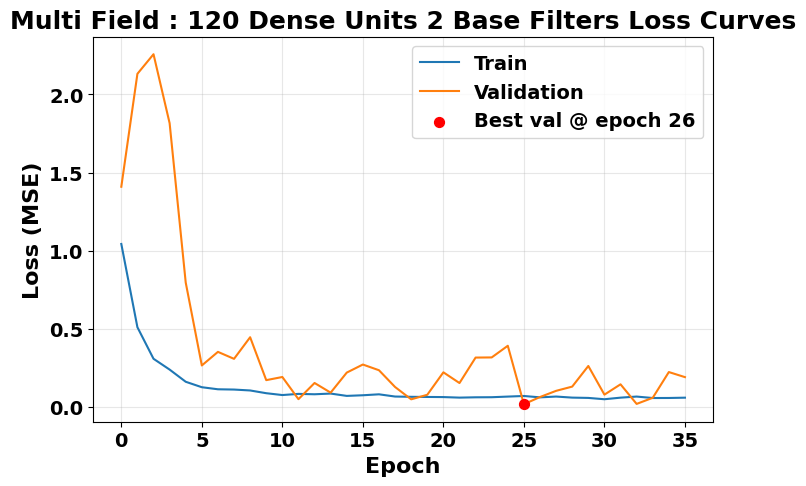

In [40]:
# After training, loss curve plotting
plot_loss_curves(history, model_name="Multi Field : 120 Dense Units 2 Base Filters",
                 save_path=os.path.join(save_dir, 'multi_initial_loss_curves.png'))

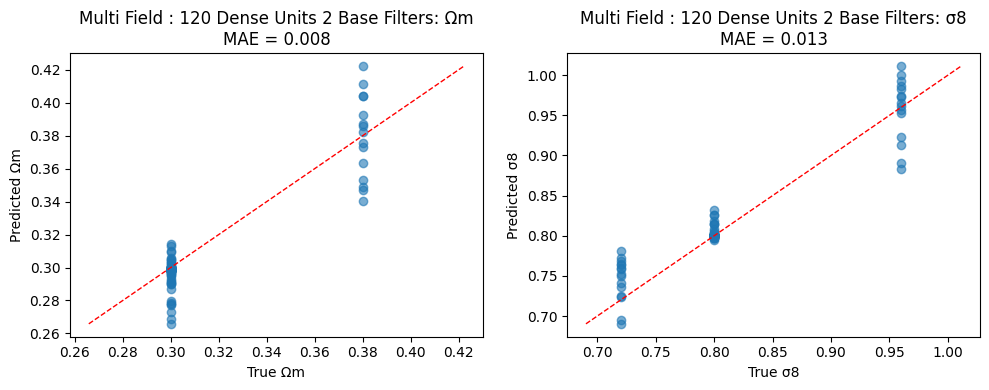

In [41]:
# After obtaining y_pred_orig, y_true_orig
plot_predictions(y_true_orig, y_pred_orig, model_name="Multi Field : 120 Dense Units 2 Base Filters",
                 save_path=os.path.join(save_dir, 'multi_initial_scatter.png'))

### Discussion

Right now, the multi‑field model (all 12 fields stacked as channels) has been trained using the same architecture that was tuned on the magnetic field (B‑field) alone. Its performance is:


| Model                | Ωm MAPE | σ8 MAPE | Parameters |
|----------------------|---------|---------|------------|
| Multi‑field (with architecture based on single field hypertuning)| 2.3%    | 1.6%    | 172,832   |

For context, the best perfomance on the B field from last notebook was

| Model                | Ωm MAPE | σ8 MAPE | Parameters |
|----------------------|---------|---------|------------|
| B‑field (hypertuned in last notebook)| 3.7%    | 2.9%    | 172,832   |

So far, as expected, the multi-field comfortably beats the single field model. But from the CAMELS paper, B was a middle of the pack field so im interested to see how multi field stacks up againast the best single field perfomances

## Next Steps

1. I will now train **each individual field** separately using this same fixed architecture. This will give a fair comparison of how much cosmological information each field contains on its own, under identical model capacity.


Then, because the multi‑field model has 12 input channels, it may require **higher capacity** (e.g., more filters or a larger dense head) to fully exploit the additional information. I expect that with the current capacity, the best single‑field model may still outperform the multi‑field model.


2. Therefore, after training all single‑field models, I will perform a separate hyperparameter search for the multi‑field configuration to find its optimal capacity, aiming to show that combining fields indeed yields superior results as per the paper that im following

# Single‑field performance (trained and tested on the same field)

To assess how much cosmological information each individual field carries, I will train (in the cells below) a separate model for each of the 12 fields. The architecture is the same as the one used for the magnetic field (B‑field) after hyperparameter tuning, i.e.:

- `base_filters = 2`
- `dense_units = 120`
- `dropout = 0.3`
- `learning_rate = 0.001`
- `batch_size = 16`

For each field, I will use the same training/validation/test splits (based on macrostates) and the same sample weights to correct for class imbalance. The model is trained for up to 50 epochs with early stopping (patience 8) on the validation loss. After training, I compute the mean absolute percentage error (MAPE) for both Ωm and σ8 on the test set. 


I think this gives a fair comparison because any difference in performance can be attributed solely to the field itself, not to differences in model capacity.

In [42]:
# Best hyperparameters from single‑field tuning based on B field from last notebook
best_base_filters = 2
best_dense_units = 120
best_dropout = 0.3
best_lr = 0.001
batch_size = 16
patience = 8
epochs = 50

In [43]:
# Setting up plot directories
base_plots_dir = r"C:\Users\makan\ML Y3 PHYSICS\camels project\camels\multi_field_plots"
scatter_dir = os.path.join(base_plots_dir, "scatter")
loss_dir = os.path.join(base_plots_dir, "loss")
os.makedirs(scatter_dir, exist_ok=True)
os.makedirs(loss_dir, exist_ok=True)


========== Training on field: Mgas ==========


C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - loss: 1.2243 - mae: 0.7788 - val_loss: 1.8920 - val_mae: 0.7474
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.5549 - mae: 0.5377 - val_loss: 3.9722 - val_mae: 1.4431
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.2790 - mae: 0.3808 - val_loss: 5.1675 - val_mae: 1.6553
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.2140 - mae: 0.3347 - val_loss: 5.2054 - val_mae: 1.6468
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.1597 - mae: 0.2785 - val_loss: 4.0614 - val_mae: 1.4927
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.1471 - mae: 0.2567 - val_loss: 2.6085 - val_mae: 1.1209
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.1095 - mae: 0.2121 - val_loss: 1.1816 - val_mae: 0.7319
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.1195 - mae: 0.2181 - val_loss: 0.3309 - val_mae: 0.3219
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.10

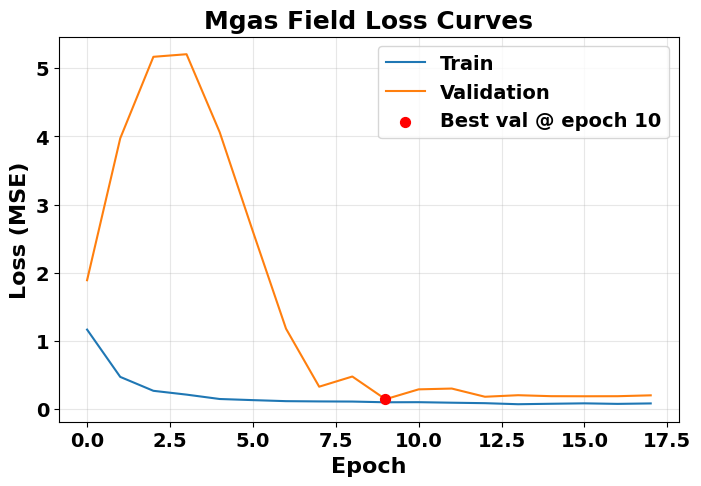

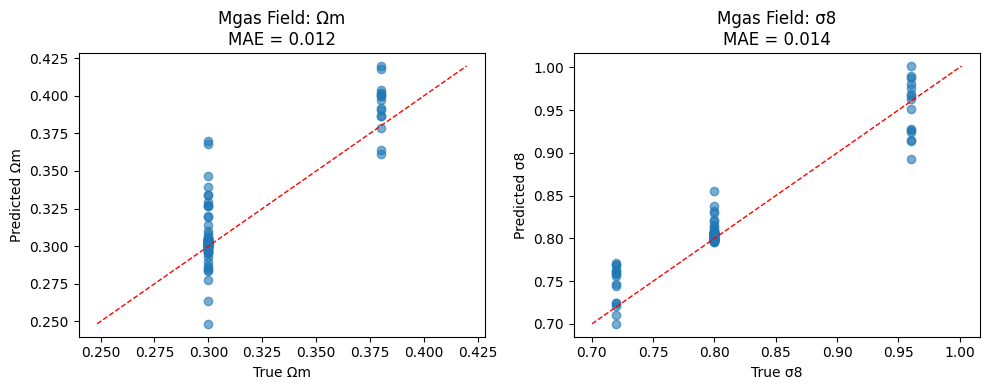


========== Training on field: Vgas ==========


C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - loss: 1.0465 - mae: 0.7181 - val_loss: 1.2184 - val_mae: 0.4381
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.6485 - mae: 0.5523 - val_loss: 1.0428 - val_mae: 0.6108
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.3900 - mae: 0.4305 - val_loss: 0.9649 - val_mae: 0.6102
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.3249 - mae: 0.3838 - val_loss: 0.7471 - val_mae: 0.5557
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.2157 - mae: 0.3214 - val_loss: 0.6724 - val_mae: 0.5390
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.2120 - mae: 0.3225 - val_loss: 0.5319 - val_mae: 0.5345
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.1419 - mae: 0.2553 - val_loss: 0.2962 - val_mae: 0.3720
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.1250 - mae: 0.2471 - val_loss: 0.2601 - val_mae: 0.3337
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.11

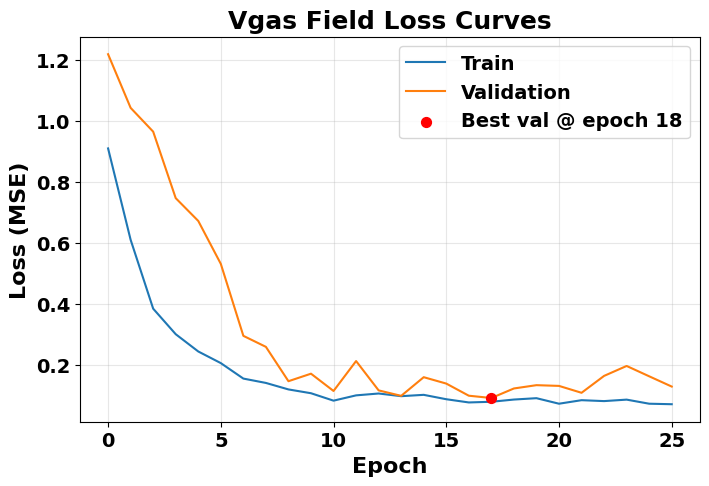

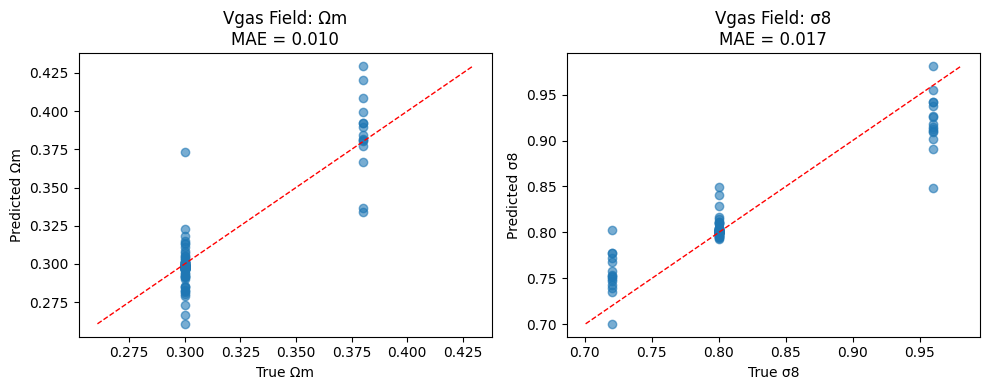


========== Training on field: T ==========


C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - loss: 1.3805 - mae: 0.8505 - val_loss: 1.7570 - val_mae: 0.6898
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.5985 - mae: 0.5758 - val_loss: 2.8162 - val_mae: 1.1395
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.3866 - mae: 0.4582 - val_loss: 4.4123 - val_mae: 1.6087
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.2554 - mae: 0.3728 - val_loss: 5.6660 - val_mae: 1.8982
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.1925 - mae: 0.3250 - val_loss: 5.6177 - val_mae: 1.9024
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.1474 - mae: 0.2789 - val_loss: 3.5965 - val_mae: 1.5695
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1422 - mae: 0.2586 - val_loss: 3.2529 - val_mae: 1.4139
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.1193 - mae: 0.2347 - val_loss: 1.7384 - val_mae: 0.9860
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.11

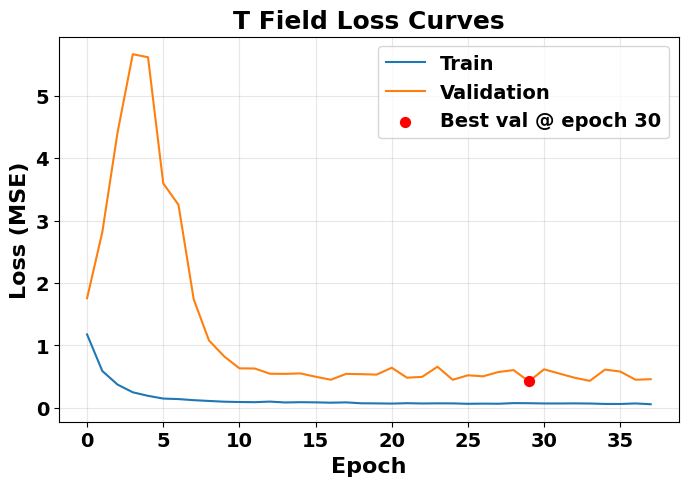

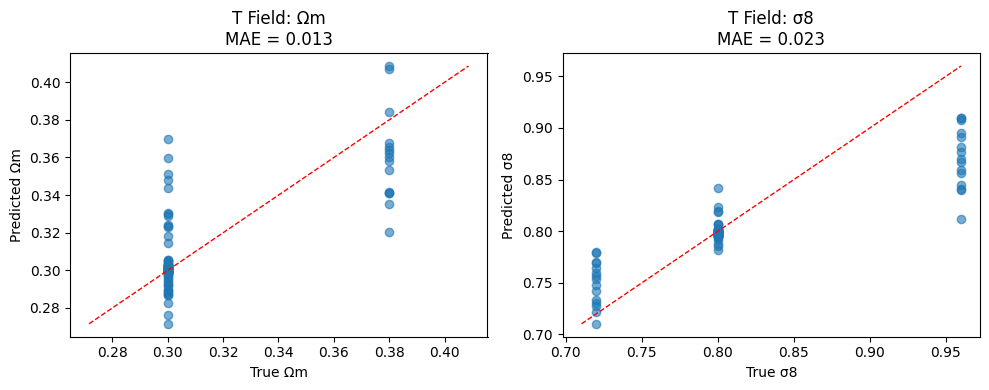


========== Training on field: Z ==========


C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - loss: 1.4260 - mae: 0.8469 - val_loss: 1.4578 - val_mae: 0.5035
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.7507 - mae: 0.6389 - val_loss: 1.5155 - val_mae: 0.5599
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.4290 - mae: 0.4644 - val_loss: 1.5116 - val_mae: 0.6340
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.2987 - mae: 0.4010 - val_loss: 1.3721 - val_mae: 0.6298
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.2187 - mae: 0.3400 - val_loss: 1.2549 - val_mae: 0.6068
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.1860 - mae: 0.3094 - val_loss: 1.1523 - val_mae: 0.6087
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.1604 - mae: 0.2828 - val_loss: 1.0132 - val_mae: 0.5423
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1469 - mae: 0.2613 - val_loss: 1.0176 - val_mae: 0.5835
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.12

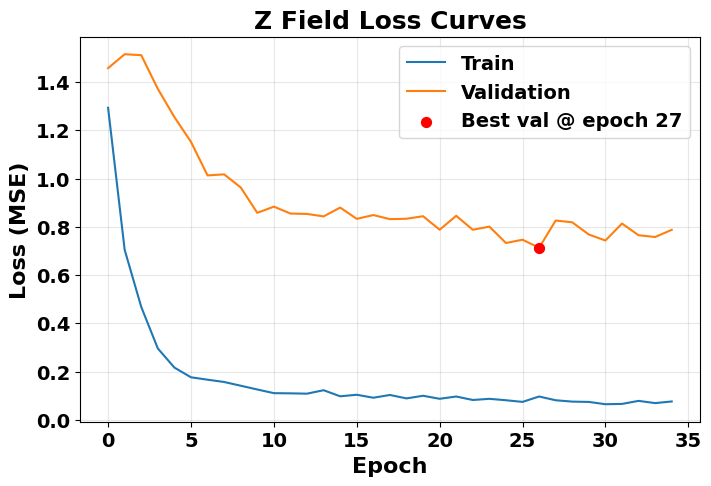

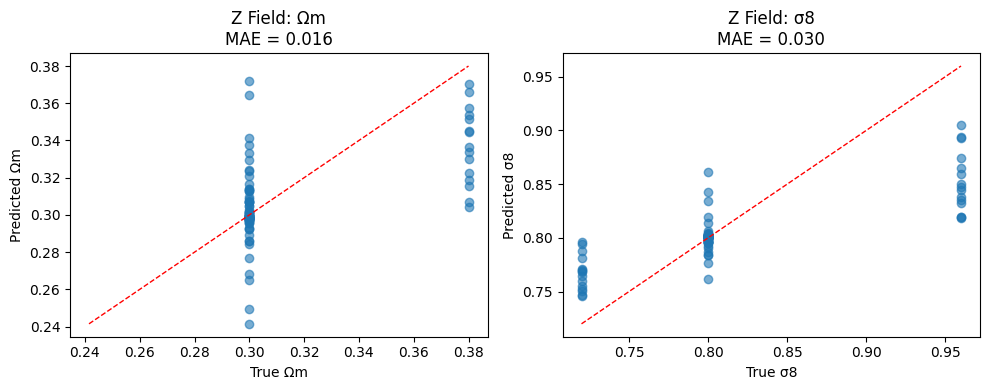


========== Training on field: HI ==========


C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - loss: 1.3700 - mae: 0.7964 - val_loss: 1.8932 - val_mae: 0.7381
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.5230 - mae: 0.5048 - val_loss: 3.0007 - val_mae: 1.1653
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.2699 - mae: 0.3807 - val_loss: 3.4941 - val_mae: 1.2932
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1778 - mae: 0.3141 - val_loss: 2.2228 - val_mae: 1.0327
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1549 - mae: 0.2713 - val_loss: 1.4177 - val_mae: 0.7848
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1634 - mae: 0.2576 - val_loss: 0.8623 - val_mae: 0.5143
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.1189 - mae: 0.2101 - val_loss: 0.5715 - val_mae: 0.3578
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1071 - mae: 0.1999 - val_loss: 0.4903 - val_mae: 0.3230
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.08

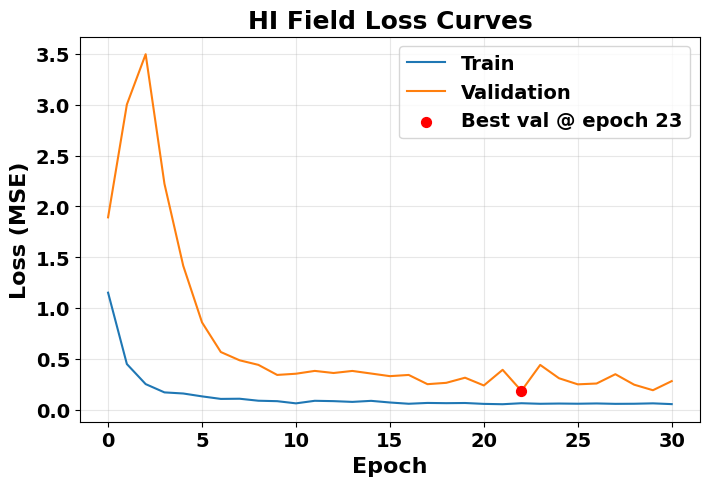

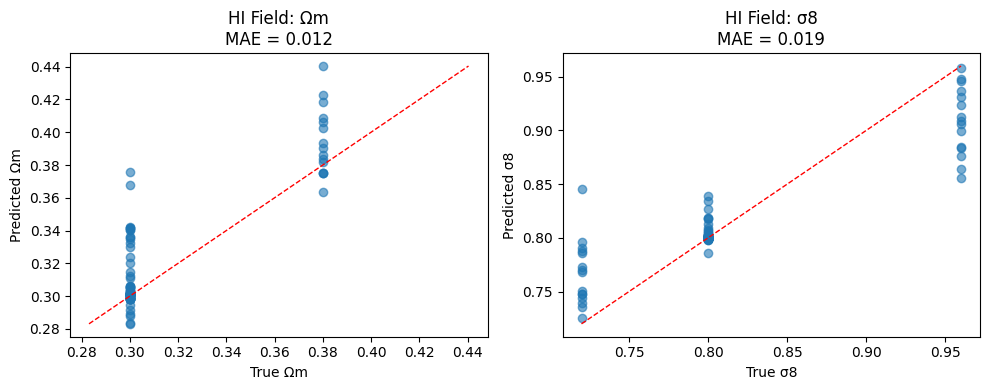


========== Training on field: ne ==========


C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 1.3615 - mae: 0.7773 - val_loss: 1.5472 - val_mae: 0.5554
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.6660 - mae: 0.5537 - val_loss: 2.4568 - val_mae: 1.0418
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.3692 - mae: 0.4357 - val_loss: 4.2532 - val_mae: 1.6531
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.2589 - mae: 0.3648 - val_loss: 5.1847 - val_mae: 1.8284
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.1645 - mae: 0.2827 - val_loss: 4.1373 - val_mae: 1.6582
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.1435 - mae: 0.2550 - val_loss: 2.6714 - val_mae: 1.2637
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.1420 - mae: 0.2365 - val_loss: 1.8250 - val_mae: 0.9810
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.1336 - mae: 0.2281 - val_loss: 0.6514 - val_mae: 0.3918
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.12

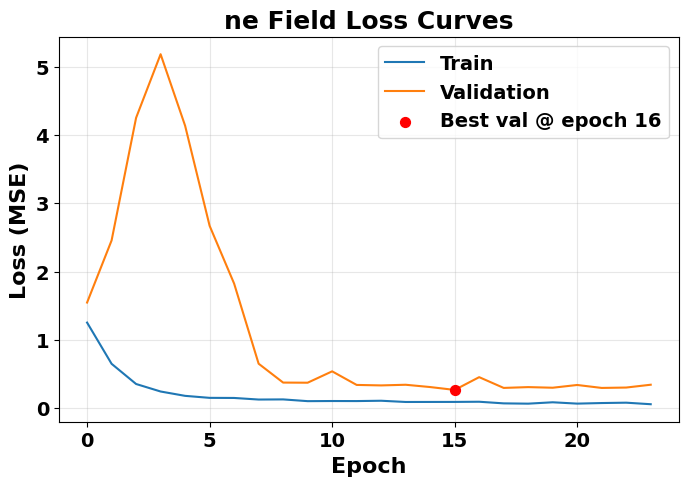

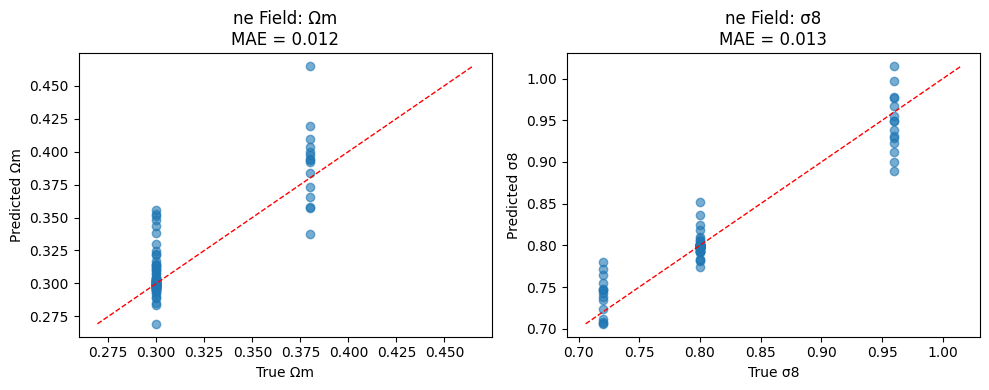


========== Training on field: B ==========


C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - loss: 1.4925 - mae: 0.8532 - val_loss: 1.5927 - val_mae: 0.5784
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.6107 - mae: 0.5638 - val_loss: 2.0182 - val_mae: 0.8053
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.3323 - mae: 0.4259 - val_loss: 1.8917 - val_mae: 0.7751
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.2805 - mae: 0.3770 - val_loss: 1.3999 - val_mae: 0.5910
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.1977 - mae: 0.3112 - val_loss: 1.1596 - val_mae: 0.5059
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1641 - mae: 0.2698 - val_loss: 0.9564 - val_mae: 0.4531
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1457 - mae: 0.2489 - val_loss: 0.8218 - val_mae: 0.4205
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.1074 - mae: 0.2109 - val_loss: 0.7624 - val_mae: 0.4101
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.11

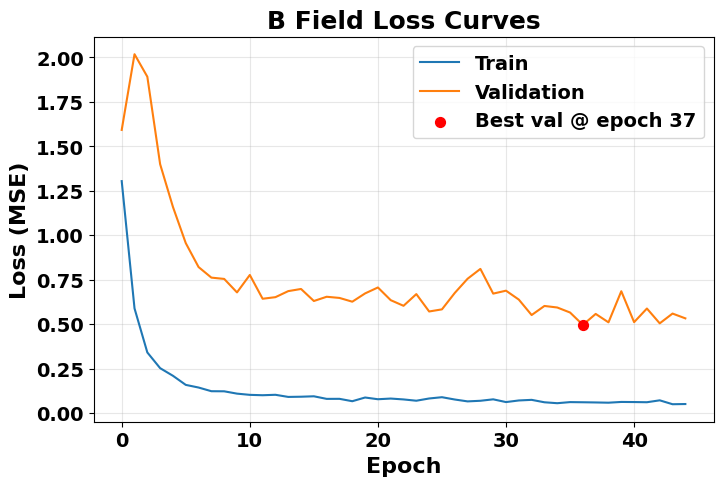

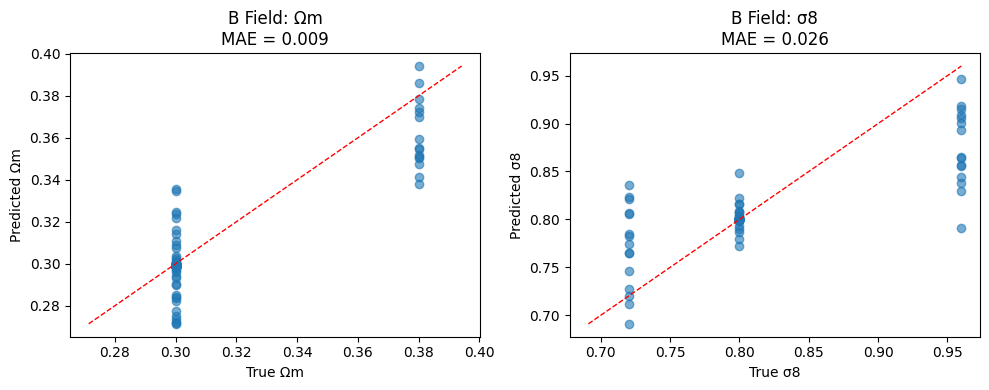


========== Training on field: MgFe ==========


C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - loss: 1.5458 - mae: 0.8320 - val_loss: 1.6705 - val_mae: 0.6609
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.7743 - mae: 0.6242 - val_loss: 2.1283 - val_mae: 0.8883
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.4471 - mae: 0.4754 - val_loss: 2.8369 - val_mae: 1.0784
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.3472 - mae: 0.4329 - val_loss: 3.0728 - val_mae: 1.1147
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.2538 - mae: 0.3808 - val_loss: 2.4478 - val_mae: 0.9457
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.2132 - mae: 0.3346 - val_loss: 1.9942 - val_mae: 0.8055
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.1706 - mae: 0.3013 - val_loss: 1.6464 - val_mae: 0.7216
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.1521 - mae: 0.2736 - val_loss: 1.4914 - val_mae: 0.6745
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.13

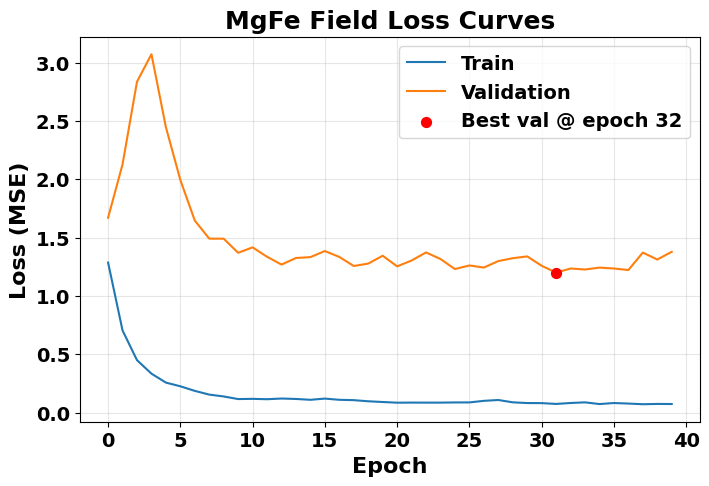

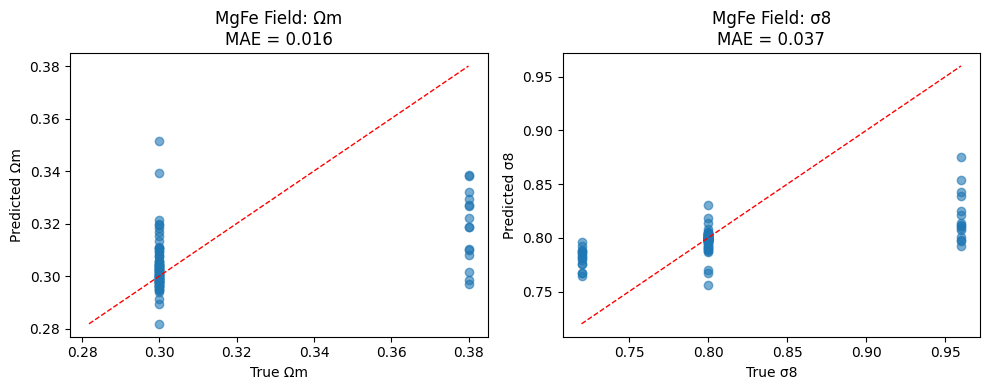


========== Training on field: Mcdm ==========


C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - loss: 1.2575 - mae: 0.7879 - val_loss: 1.5046 - val_mae: 0.6251
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.4596 - mae: 0.4843 - val_loss: 1.8090 - val_mae: 0.9184
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.2417 - mae: 0.3601 - val_loss: 2.0780 - val_mae: 1.1277
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.2045 - mae: 0.3202 - val_loss: 1.6625 - val_mae: 1.0108
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.1670 - mae: 0.2780 - val_loss: 1.1107 - val_mae: 0.7804
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.1364 - mae: 0.2411 - val_loss: 0.4492 - val_mae: 0.4543
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1215 - mae: 0.2294 - val_loss: 0.3869 - val_mae: 0.3657
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.1118 - mae: 0.2005 - val_loss: 0.2698 - val_mae: 0.2409
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.08

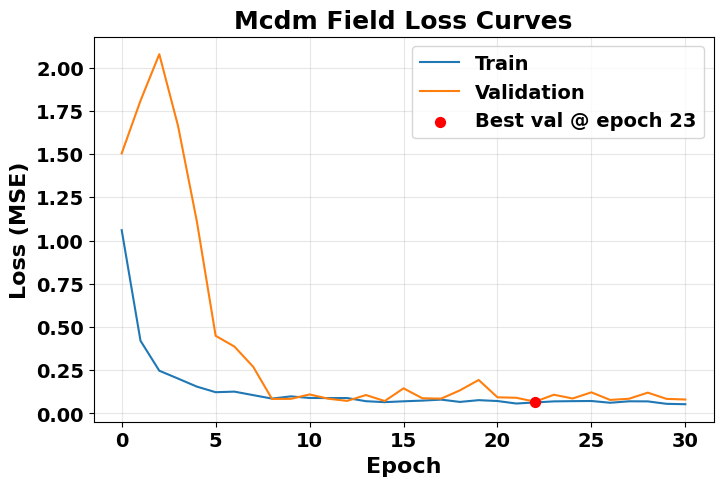

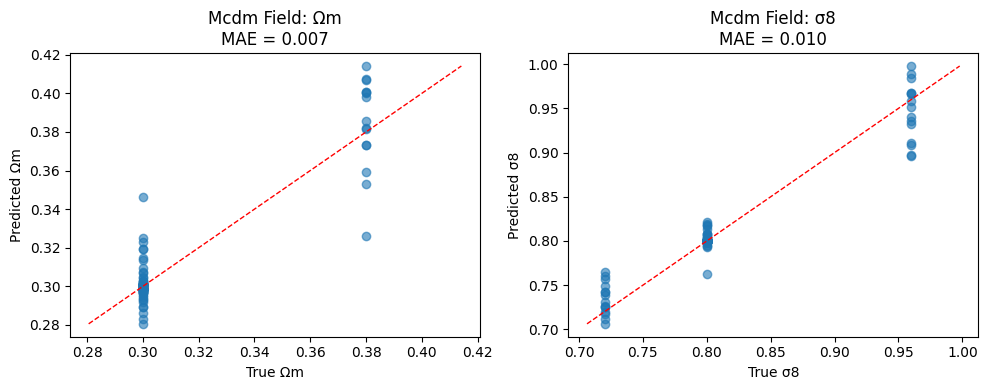


========== Training on field: Vcdm ==========


C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - loss: 1.3425 - mae: 0.8264 - val_loss: 1.3547 - val_mae: 0.4725
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.7126 - mae: 0.5715 - val_loss: 1.2262 - val_mae: 0.4352
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.3167 - mae: 0.3996 - val_loss: 1.1069 - val_mae: 0.4852
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.2483 - mae: 0.3520 - val_loss: 0.8942 - val_mae: 0.5041
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.2176 - mae: 0.3294 - val_loss: 0.7647 - val_mae: 0.4772
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.1535 - mae: 0.2650 - val_loss: 0.4727 - val_mae: 0.3974
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1361 - mae: 0.2472 - val_loss: 0.2357 - val_mae: 0.2820
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1215 - mae: 0.2251 - val_loss: 0.3187 - val_mae: 0.4197
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.11

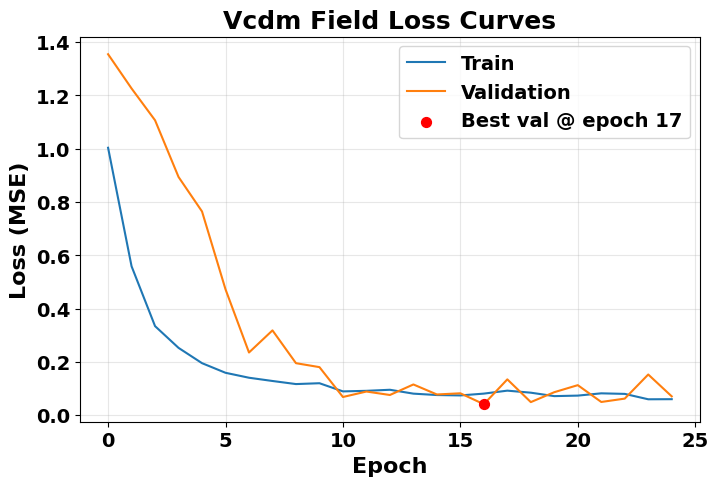

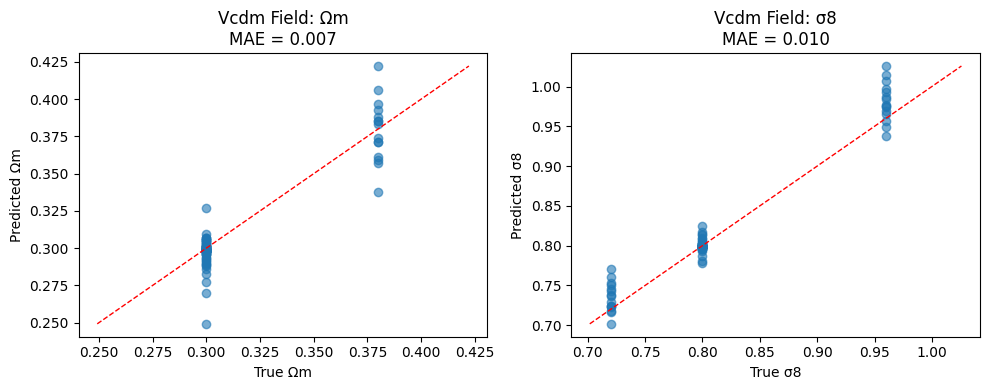


========== Training on field: Mstar ==========


C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - loss: 1.4752 - mae: 0.8434 - val_loss: 1.6462 - val_mae: 0.6264
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.6687 - mae: 0.5803 - val_loss: 2.1668 - val_mae: 0.8642
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.3796 - mae: 0.4443 - val_loss: 2.5419 - val_mae: 1.0206
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.2387 - mae: 0.3677 - val_loss: 1.6842 - val_mae: 0.7757
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.1964 - mae: 0.3228 - val_loss: 1.2480 - val_mae: 0.5926
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.1635 - mae: 0.2900 - val_loss: 0.9907 - val_mae: 0.5067
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1379 - mae: 0.2576 - val_loss: 0.8271 - val_mae: 0.4449
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.1320 - mae: 0.2362 - val_loss: 0.6918 - val_mae: 0.4217
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.11

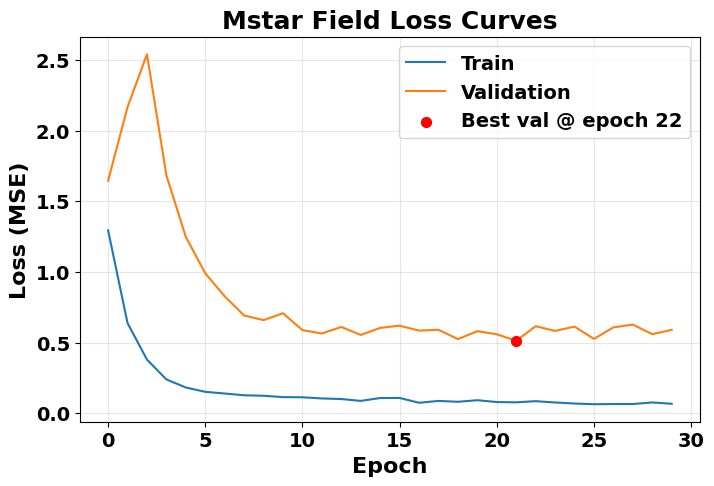

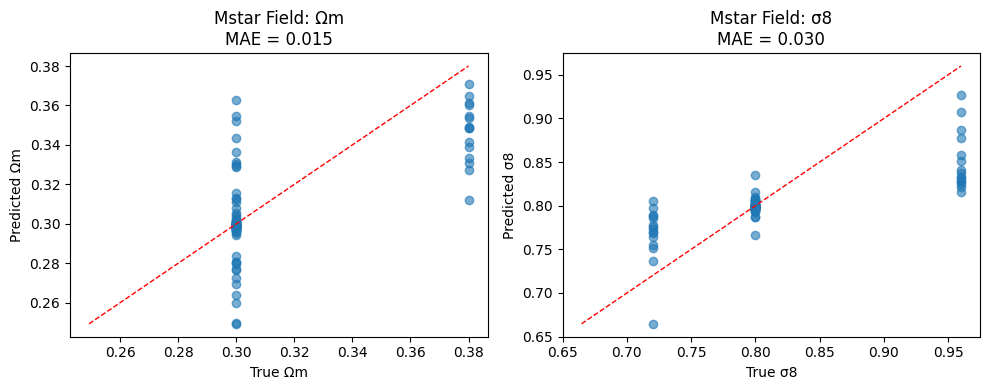


========== Training on field: Mtot ==========


C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 1.3381 - mae: 0.8148 - val_loss: 2.4250 - val_mae: 0.9368
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.4452 - mae: 0.4844 - val_loss: 3.8682 - val_mae: 1.3644
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.2767 - mae: 0.3815 - val_loss: 5.1858 - val_mae: 1.5953
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1942 - mae: 0.3230 - val_loss: 3.7192 - val_mae: 1.3973
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.1651 - mae: 0.2786 - val_loss: 2.1659 - val_mae: 1.0532
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1045 - mae: 0.2139 - val_loss: 0.9666 - val_mae: 0.6719
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.1045 - mae: 0.2044 - val_loss: 0.4298 - val_mae: 0.4062
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1055 - mae: 0.1975 - val_loss: 0.2506 - val_mae: 0.2486
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.10

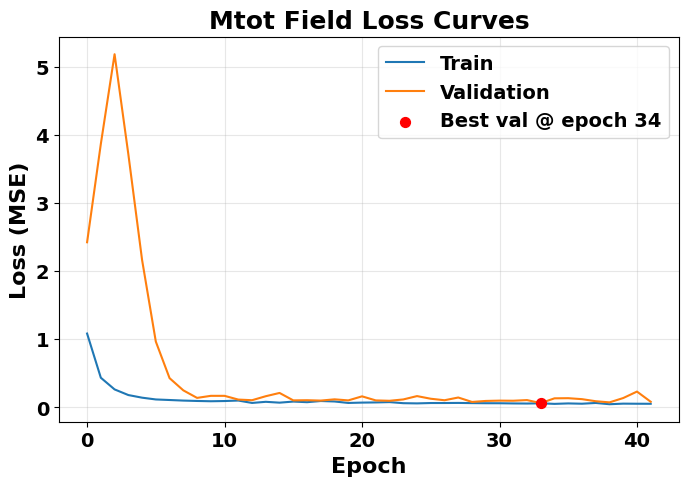

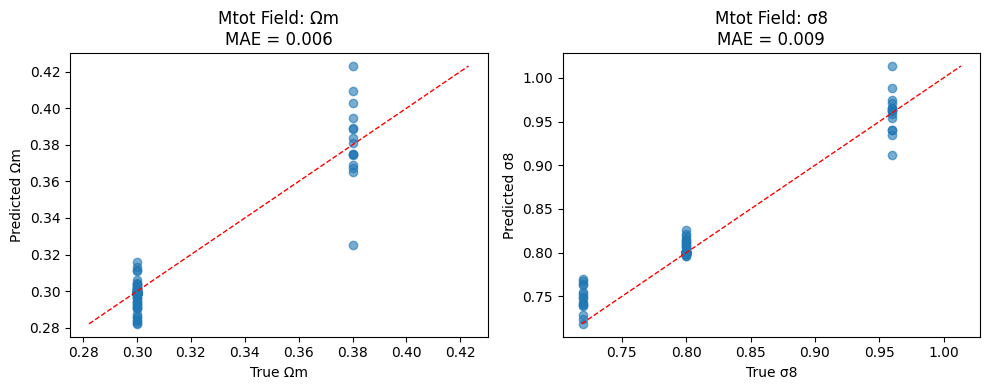

In [44]:
# Preparing a list to collect results
results_list = []

# Looping over each of the 12 astrophysical fields
for field in fields:
    print(f"\n========== Training on field: {field} ==========")

    # 1. Loading the full map for this field
    fname = f'Maps_{field}_IllustrisTNG_1P_z=0.00.npy'
    full_path = os.path.join(data_folder, fname)
    arr = np.load(full_path).astype(np.float32)   # shape (990,256,256)

    # 2. Applying log transform where needed (same rule as before), see justification above
    if field in ['Vgas', 'Vcdm']:
        X = arr  # keep linear
        transform_f = 'linear'
    else:
        X = np.log10(arr + 1e-5)
        transform_f = 'log'

    # 3. Computing mean and std on training set only (to avoid data leakage)
    X_train_raw = X[train_idx]                     # (795,256,256)
    mean_f = X_train_raw.mean(keepdims=True)       # Mean pixel value for normalization
    std_f  = X_train_raw.std(keepdims=True) + 1e-8 # Standard deviation (small epsilon for safety)

    # 4. Normalising the entire array (applying to all splits to avoid recomputing later)
    X_norm = (X - mean_f) / std_f
    # Add channel dimension (required for Conv2D input)
    X_norm = X_norm[..., np.newaxis]               # Shape becomes (990,256,256,1)

    # 5. Splitting the normalised data into train/validation/test sets using the pre‑computed indices
    X_train_f = X_norm[train_idx]
    X_val_f   = X_norm[val_idx]
    X_test_f  = X_norm[test_idx]

    # 6. Building a fresh model instance with the fixed single‑field architecture
    model_f, param_desc_f = build_camels_cnn(
        input_shape=(256,256,1),
        num_outputs=2,
        base_filters=best_base_filters,
        dense_units=best_dense_units,
        dropout=best_dropout
    )
    # Compiling the model with the best learning rate found from hyperparameter tuning
    model_f.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_lr),
        loss='mse',
        metrics=['mae']
    )

    # 7. Training the model with early stopping to prevent overfitting
    early_stop = EarlyStopping(monitor='val_loss', patience=patience,
                               restore_best_weights=True)
    history_f = model_f.fit(
        X_train_f, y_train,
        validation_data=(X_val_f, y_val),
        epochs=epochs,
        batch_size=batch_size,
        sample_weight=sample_weights_train,   # Applying sample weights to address class imbalance
        callbacks=[early_stop],
        verbose=1
    )

    # 8. Evaluating the trained model on the held‑out test set
    y_true_f, y_pred_f = get_predictions(model_f, X_test_f, scaler, y_test)
    metrics_f = regression_report(y_true_f, y_pred_f, param_names=['Ωm', 'σ8'])

    # 8b. Plotting and saving loss curves and prediction scatter plots for later inspection
    plot_loss_curves(history_f, model_name=f"{field} Field",
                     save_path=os.path.join(loss_dir, f"loss_{field}.png"))
    plot_predictions(y_true_f, y_pred_f, model_name=f"{field} Field",
                     save_path=os.path.join(scatter_dir, f"pred_{field}.png"))

    # 9. Adding metadata to the results dictionary for logging and later comparison, just a bit of context is nice
    metrics_f['field'] = field
    metrics_f['model_name'] = f'single_field_{field}'
    metrics_f['params_total'] = model_f.count_params()
    metrics_f['timestamp'] = time.strftime('%Y-%m-%d %H:%M:%S')
    # Including all hyperparameters used for this model
    for k, v in param_desc_f.items():
        metrics_f[k] = v

    # 10. Appending the metrics for this field to the results list
    results_list.append(metrics_f)

    # Saving the trained model and its preprocessing parameters for cross‑field evaluation later
    model_f.save(f'single_field_model_{field}.keras')
    np.savez(f'single_field_preproc_{field}.npz', mean=mean_f, std=std_f, transform=transform_f)

In [45]:
# Converting results to DataFrame and save to CSV
df_results = pd.DataFrame(results_list)
csv_file = 'single_field_results.csv'
df_results.to_csv(csv_file, index=False)
print(f"\nAll single‑field results saved to {csv_file}")


All single‑field results saved to single_field_results.csv


## Discussion : Single vs Multi Field


In the previous sections, I performed a grid search on the magnetic field (B‑field) to find optimal hyperparameters for the single‑field architecture. The best combination found was:

- `base_filters = 2`
- `dense_units = 120`
- `dropout = 0.3`
- `learning_rate = 0.001`
- `batch_size = 16`

I then **fixed** this architecture and used it to train **all** single‑field models. This ensures a fair comparison so that any difference in performance can be attributed solely to the information content of the field, not to varying model capacity.

I then applied the **same** architecture to the multi‑field model, where 12 fields are stacked as input channels (shape 256×256×12). The results are summarised below:

| Model                        | Ωm MAPE | σ8 MAPE | Trainable parameters |
|------------------------------|---------|---------|----------------------|
| Best single‑field (Mtot)     | 1.9%   | 1.2%   | 172,832             |
| Multi‑field (with architecture based on single field hypertuning)        | 2.3%    | 1.6%    |172,832             |

Although the multi‑field model achieves a very low σ8 MAPE (1.6%), it does **not** outperform the best single‑field model, which is what I expected, though it came close. 

What im thinking is the architecture tuned for a single‑channel input is not optimal for a 12‑channel input. The model may need:

- **Higher convolutional capacity** (larger `base_filters`) to extract cross‑channel features,
- **A larger dense head** to combine the additional information,

Therefore, I will now perform a separate grid search specifically for the multi‑field model. 

I will expand hyperparameter space (e.g., `base_filters` in {2,4,6}, `dense_units` up to 240) to find the optimal capacity for the multi‑channel input. After this tuning, I expect the multi‑field model to surpass all single‑field results, confirming that combining multiple fields yields additional cosmological information in agreement with the paper that im following Villaescusa‑Navarro et al. (2021).

Thats my hypothesis going into this

## Hypertuning Multifield

Same approach as single field, but just larger values so a larger space

In [46]:
# Loading the normalised multi‑field training data (only once)
X_train_multi = (X_log_mmap[train_idx] - mean) / std
print("X_train_multi shape:", X_train_multi.shape)  # (795, 256, 256, 12)

X_train_multi shape: (795, 256, 256, 12)


In [48]:
# Ensuring required variables exist before proceeding (useful just in case if cells are re‑run out of order, had that issue)
if 'groups' not in locals():
    # Recreating the groups array: each image belongs to a macrostate (15 images per macrostate)
    groups = np.repeat(train_macro, 15)               # shape (795,)

if 'sample_weights_train' not in locals():
    # Recomputing sample weights to correct for class imbalance in the training set
    unique_macros, counts = np.unique(train_macro, return_counts=True)
    freq = counts / len(train_macro)
    weight_per_macro = 1.0 / freq
    weight_per_macro = weight_per_macro / weight_per_macro.mean()   # Normalising so mean weight is 1
    groups_train = np.repeat(train_macro, 15)
    # Mapping each training image to its corresponding macrostate weight
    sample_weights_train = np.array([
        weight_per_macro[np.where(unique_macros == m)[0][0]]
        for m in groups_train
    ]).astype(np.float32)

# Setting up GroupKFold with 2 splits so it keeps all images of a macrostate together in the same fold
gkf = GroupKFold(n_splits=2)

In [49]:
# Define the hyperparameter grid
# A biger grid was not possible due to lack of computing power

param_grid = {
    'model__base_filters': [2, 4, 6],         
    'model__dense_units': [24, 120, 180], 
    'model__dropout': [0.2],              
    'model__lr': [0.001],                
    'batch_size': [16]                    
}


In [46]:
# Build function for multi‑channel input
def build_model(base_filters=2, dense_units=120, dropout=0.3, lr=0.001):
    model, _ = build_camels_cnn(
        input_shape=(256, 256, 12),   # 12 channels
        num_outputs=2,
        base_filters=base_filters,
        dense_units=dense_units,
        dropout=dropout
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model

In [46]:
# Grid search loop with progress tracking
param_keys = list(param_grid.keys())
param_combinations = list(product(*param_grid.values()))
total_combos = len(param_combinations)
total_fits = total_combos * 2

Total hyperparameter combinations: 9
Total fits (2 folds each): 18


In [33]:
# Printing the total number of hyperparameter combinations and the number of model fits (2 folds per combination)
# Helps to keep track of stuff
print(f"Total hyperparameter combinations: {total_combos}")
print(f"Total fits (2 folds each): {total_fits}")

# Initialising a list to store results and recording the start time for progress tracking
results = []
start_time = time.time()

# Iterating over each hyperparameter combination
for combo_idx, param_vals in enumerate(param_combinations, 1):
    # Creating a dictionary mapping parameter names to their current values
    params = dict(zip(param_keys, param_vals))
    print(f"\n=== Combo {combo_idx}/{total_combos} | Params: {params} ===")
    
    fold_scores = []  # Storing validation MAE scores for the two folds
    # Performing 2-fold cross‑validation with macrostate‑respecting splits
    for fold_idx, (fold_train_idx, fold_val_idx) in enumerate(gkf.split(X_train_multi, y_train, groups=groups), 1):
        print(f"  Fold {fold_idx}/2")
        fold_start = time.time()
        
        # Splitting the data into training and validation sets for this fold
        X_fold_tr = X_train_multi[fold_train_idx]
        X_fold_val = X_train_multi[fold_val_idx]
        y_fold_tr = y_train[fold_train_idx]
        y_fold_val = y_train[fold_val_idx]
        w_fold_tr = sample_weights_train[fold_train_idx]  # Extracting sample weights for the training fold

        # Extracting model‑specific hyperparameters (stripping the 'model__' prefix)
        model_kwargs = {k.replace("model__", ""): v for k, v in params.items() if k.startswith("model__")}
        batch_size = params["batch_size"]

        # Building a fresh model instance with the current hyperparameters
        m = build_model(**model_kwargs)

        # Training the model on the fold training data with early stopping
        m.fit(
            X_fold_tr, y_fold_tr,
            sample_weight=w_fold_tr,                  # Applying sample weights to combat class imbalance
            validation_data=(X_fold_val, y_fold_val), # Monitoring validation performance
            epochs=100,
            batch_size=batch_size,
            callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)],
            verbose=2,
        )

        # Generating predictions on the validation fold and computing MAE
        preds = m.predict(X_fold_val)
        score = mean_absolute_error(y_fold_val, preds)
        fold_scores.append(score)

        # Cleaning up, so here im clearing the Keras session and deleting the model to free memory
        keras.backend.clear_session()
        del m
        gc.collect()
        
        fold_time = time.time() - fold_start
        print(f"    Fold {fold_idx} done in {fold_time:.2f}s")

    # Computing the mean MAE across the two folds for this hyperparameter combination
    mean_mae = np.mean(fold_scores)
    print(f"  Combo {combo_idx} mean MAE: {mean_mae:.4f}")
    results.append({"params": params, "mae": mean_mae})
    
    # Estimating the remaining runtime for the grid search
    elapsed = time.time() - start_time
    avg_time_per_combo = elapsed / combo_idx
    remaining_combos = total_combos - combo_idx
    est_remaining = avg_time_per_combo * remaining_combos
    print(f"  Elapsed: {elapsed/60:.1f} min, Est. remaining: {est_remaining/60:.1f} min")

# Finding the best hyperparameter combination (lowest mean MAE across folds)
best = min(results, key=lambda x: x["mae"])
print("\nBest params:", best["params"])
print("Best MAE:   ", best["mae"])

Total hyperparameter combinations: 9
Total fits (2 folds each): 18

=== Combo 1/9 | Params: {'model__base_filters': 2, 'model__dense_units': 24, 'model__dropout': 0.2, 'model__lr': 0.001, 'batch_size': 16} ===
  Fold 1/2


C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/100
25/25 - 40s - 2s/step - loss: 1.3914 - mae: 0.7863 - val_loss: 1.1042 - val_mae: 0.4226
Epoch 2/100
25/25 - 3s - 124ms/step - loss: 0.6565 - mae: 0.5430 - val_loss: 1.0853 - val_mae: 0.4171
Epoch 3/100
25/25 - 2s - 69ms/step - loss: 0.4660 - mae: 0.4285 - val_loss: 1.0465 - val_mae: 0.4405
Epoch 4/100
25/25 - 2s - 64ms/step - loss: 0.3263 - mae: 0.3539 - val_loss: 1.0125 - val_mae: 0.4768
Epoch 5/100
25/25 - 2s - 64ms/step - loss: 0.2733 - mae: 0.2980 - val_loss: 0.9903 - val_mae: 0.5234
Epoch 6/100
25/25 - 2s - 65ms/step - loss: 0.1554 - mae: 0.2357 - val_loss: 0.9353 - val_mae: 0.5233
Epoch 7/100
25/25 - 2s - 61ms/step - loss: 0.1676 - mae: 0.2429 - val_loss: 0.8747 - val_mae: 0.5257
Epoch 8/100
25/25 - 2s - 62ms/step - loss: 0.1650 - mae: 0.2391 - val_loss: 0.6763 - val_mae: 0.3949
Epoch 9/100
25/25 - 2s - 66ms/step - loss: 0.1671 - mae: 0.2220 - val_loss: 0.6095 - val_mae: 0.3939
Epoch 10/100
25/25 - 2s - 69ms/step - loss: 0.1219 - mae: 0.1966 - val_loss: 0.4955 - val_m

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/100
26/26 - 52s - 2s/step - loss: 1.7179 - mae: 0.9251 - val_loss: 0.8598 - val_mae: 0.3480
Epoch 2/100
26/26 - 20s - 785ms/step - loss: 0.6734 - mae: 0.5832 - val_loss: 0.8637 - val_mae: 0.4783
Epoch 3/100
26/26 - 4s - 158ms/step - loss: 0.4788 - mae: 0.4890 - val_loss: 1.2099 - val_mae: 0.7916
Epoch 4/100
26/26 - 2s - 65ms/step - loss: 0.3067 - mae: 0.3661 - val_loss: 1.7930 - val_mae: 1.0313
Epoch 5/100
26/26 - 2s - 61ms/step - loss: 0.2583 - mae: 0.3357 - val_loss: 2.3467 - val_mae: 1.1858
Epoch 6/100
26/26 - 2s - 63ms/step - loss: 0.2607 - mae: 0.3116 - val_loss: 2.9866 - val_mae: 1.3456
Epoch 7/100
26/26 - 2s - 63ms/step - loss: 0.2346 - mae: 0.2929 - val_loss: 2.8950 - val_mae: 1.3424
Epoch 8/100
26/26 - 2s - 77ms/step - loss: 0.2101 - mae: 0.2615 - val_loss: 2.3650 - val_mae: 1.2044
Epoch 9/100
26/26 - 2s - 60ms/step - loss: 0.2139 - mae: 0.2546 - val_loss: 2.2336 - val_mae: 1.1446
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step
    Fold 2 done in 161.38s
  Combo 1 mean MAE: 0

...

Epoch 1/100
26/26 - 57s - 2s/step - loss: 2.1362 - mae: 1.0417 - val_loss: 1.3531 - val_mae: 0.8187
Epoch 2/100
26/26 - 12s - 457ms/step - loss: 0.7738 - mae: 0.6429 - val_loss: 0.9032 - val_mae: 0.5700
Epoch 3/100
26/26 - 10s - 370ms/step - loss: 0.5430 - mae: 0.5566 - val_loss: 0.7037 - val_mae: 0.4527
Epoch 4/100
26/26 - 4s - 153ms/step - loss: 0.3735 - mae: 0.4546 - val_loss: 0.8410 - val_mae: 0.5794
Epoch 5/100
26/26 - 4s - 137ms/step - loss: 0.3372 - mae: 0.4371 - val_loss: 0.7891 - val_mae: 0.5614
Epoch 6/100
26/26 - 3s - 131ms/step - loss: 0.2158 - mae: 0.3519 - val_loss: 0.8648 - val_mae: 0.5918
Epoch 7/100
26/26 - 4s - 152ms/step - loss: 0.1786 - mae: 0.3042 - val_loss: 1.1116 - val_mae: 0.7206
Epoch 8/100
26/26 - 4s - 138ms/step - loss: 0.1330 - mae: 0.2646 - val_loss: 0.8947 - val_mae: 0.6343
Epoch 9/100
26/26 - 3s - 129ms/step - loss: 0.1272 - mae: 0.2472 - val_loss: 1.1359 - val_mae: 0.7324
Epoch 10/100
26/26 - 4s - 137ms/step - loss: 0.1257 - mae: 0.2341 - val_loss: 0.95

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/100
25/25 - 69s - 3s/step - loss: 1.9424 - mae: 1.0178 - val_loss: 1.0992 - val_mae: 0.4959
Epoch 2/100
25/25 - 10s - 413ms/step - loss: 0.7241 - mae: 0.6534 - val_loss: 1.0274 - val_mae: 0.4429
Epoch 3/100
25/25 - 3s - 138ms/step - loss: 0.4401 - mae: 0.5062 - val_loss: 0.9179 - val_mae: 0.4002
Epoch 4/100
25/25 - 4s - 146ms/step - loss: 0.3034 - mae: 0.4243 - val_loss: 0.8965 - val_mae: 0.5050
Epoch 5/100
25/25 - 3s - 136ms/step - loss: 0.2300 - mae: 0.3646 - val_loss: 0.9520 - val_mae: 0.6088
Epoch 6/100
25/25 - 3s - 135ms/step - loss: 0.1933 - mae: 0.3254 - val_loss: 1.0982 - val_mae: 0.7446
Epoch 7/100
25/25 - 3s - 131ms/step - loss: 0.1441 - mae: 0.2835 - val_loss: 1.1435 - val_mae: 0.7744
Epoch 8/100
25/25 - 3s - 138ms/step - loss: 0.1082 - mae: 0.2438 - val_loss: 0.9787 - val_mae: 0.6963
Epoch 9/100
25/25 - 3s - 134ms/step - loss: 0.1003 - mae: 0.2263 - val_loss: 0.5253 - val_mae: 0.3801
Epoch 10/100
25/25 - 3s - 131ms/step - loss: 0.0968 - mae: 0.2071 - val_loss: 0.925

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/100
26/26 - 63s - 2s/step - loss: 1.9794 - mae: 1.0256 - val_loss: 2.1979 - val_mae: 1.2570
Epoch 2/100
26/26 - 8s - 303ms/step - loss: 0.8831 - mae: 0.7078 - val_loss: 0.8812 - val_mae: 0.5175
Epoch 3/100
26/26 - 4s - 141ms/step - loss: 0.5604 - mae: 0.5511 - val_loss: 0.7569 - val_mae: 0.5194
Epoch 4/100
26/26 - 4s - 149ms/step - loss: 0.4061 - mae: 0.4796 - val_loss: 0.9440 - val_mae: 0.6497
Epoch 5/100
26/26 - 3s - 131ms/step - loss: 0.3039 - mae: 0.4332 - val_loss: 0.8564 - val_mae: 0.6334
Epoch 6/100
26/26 - 3s - 130ms/step - loss: 0.2362 - mae: 0.3723 - val_loss: 1.6735 - val_mae: 0.9457
Epoch 7/100
26/26 - 4s - 135ms/step - loss: 0.1673 - mae: 0.3071 - val_loss: 1.1921 - val_mae: 0.8275
Epoch 8/100
26/26 - 4s - 135ms/step - loss: 0.1565 - mae: 0.2879 - val_loss: 0.9459 - val_mae: 0.6786
Epoch 9/100
26/26 - 4s - 149ms/step - loss: 0.1368 - mae: 0.2587 - val_loss: 0.8985 - val_mae: 0.6786
Epoch 10/100
26/26 - 4s - 150ms/step - loss: 0.1134 - mae: 0.2335 - val_loss: 0.9987

Best params: {'model__base_filters': 4, 'model__dense_units': 180, 'model__dropout': 0.2, 'model__lr': 0.001, 'batch_size': 16}
Best MAE:    0.1634276658296585

In [50]:
# Combining training and validation indices
combined_train_idx = np.concatenate([train_idx, val_idx])   # shape (900,)

# Combining targets
y_combined = np.concatenate([y_train, y_val])               # (900, 2)

In [51]:
# Computing sample weights for the combined set
all_macro = np.concatenate([train_macro, val_macro])        # shape (60,)
groups_combined = np.repeat(all_macro, 15)                  # shape (900,)
unique_macros, counts = np.unique(all_macro, return_counts=True)
freq = counts / len(all_macro)
weight_per_macro = 1.0 / freq
weight_per_macro = weight_per_macro / weight_per_macro.mean()
sample_weights_combined = np.array([weight_per_macro[np.where(unique_macros == m)[0][0]] 
                                    for m in groups_combined]).astype(np.float32)

In [52]:
# Creating a new training generator for the combined set
train_gen_combined = batch_generator(
    X_log_mmap, combined_train_idx, y_combined,
    sample_weights_combined, mean, std,
    batch_size=16, shuffle=True
)

In [53]:
# Validation generator (still using val_idx)
val_gen = batch_generator(
    X_log_mmap, val_idx, y_val,
    None, mean, std,
    batch_size=16, shuffle=False
)

In [54]:
# Building model with best hyperparameters
best_model, _ = build_camels_cnn(
    input_shape=(256,256,12),
    num_outputs=2,
    base_filters=4,
    dense_units=180,
    dropout=0.2
)

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [55]:
# Compiling best model
best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [56]:
steps_per_epoch = len(combined_train_idx) // 16 # steps per epoch
validation_steps = len(val_idx) // 16 # val steps

# fitting best model
history = best_model.fit(
    train_gen_combined,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=100,
    callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)],
    verbose=1
)

Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 57s 720ms/step - loss: 1.6935 - mae: 0.9320 - val_loss: 1.1148 - val_mae: 0.5165
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 261ms/step - loss: 0.6147 - mae: 0.5813 - val_loss: 2.3768 - val_mae: 1.0601
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 189ms/step - loss: 0.3246 - mae: 0.4205 - val_loss: 2.4985 - val_mae: 1.2195
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 190ms/step - loss: 0.1975 - mae: 0.3221 - val_loss: 1.1660 - val_mae: 0.8203
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 184ms/step - loss: 0.1182 - mae: 0.2486 - val_loss: 0.4825 - val_mae: 0.5728
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 176ms/step - loss: 0.1088 - mae: 0.2252 - val_loss: 0.1370 - val_mae: 0.2506
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 169ms/step - loss: 0.0935 - mae: 0.2039 - val_loss: 0.0965 - val_mae: 0.2220
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - loss: 0.1039 - mae: 0.1994 - val_loss: 0.0853 - val_mae: 0.1536
Epoch 9/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 

In [57]:
# generating test gen
test_gen = batch_generator(
    X_log_mmap, test_idx, y_test,
    None, mean, std,
    batch_size=16, shuffle=False
)

In [58]:
y_pred_list = [] # storing y predicted
y_true_list = [] # storing y true

# looping through batches and extracting predictions

for batch in test_gen:
    X_batch, y_batch = batch[:2]   # ignore sample weights if present
    pred = best_model.predict(X_batch, verbose=0)
    y_pred_list.append(pred)
    y_true_list.append(y_batch)
    if len(y_pred_list) * 16 >= len(test_idx):
        break

In [59]:
y_pred = np.concatenate(y_pred_list)[:len(test_idx)] 
y_true = np.concatenate(y_true_list)[:len(test_idx)]

y_pred_orig = scaler.inverse_transform(y_pred)
y_true_orig = scaler.inverse_transform(y_true)

regression_report(y_true_orig, y_pred_orig)

Ωm: MAE=0.009, MAPE=2.7%, RMSE=0.015, R²=0.743, r=0.899
σ8: MAE=0.010, MAPE=1.2%, RMSE=0.018, R²=0.937, r=0.974


{'Ωm_MAE': np.float32(0.008982469),
 'Ωm_MAPE': np.float32(2.742286),
 'Ωm_RMSE': np.float32(0.015126977),
 'Ωm_R2': 0.742571234703064,
 'Ωm_corr': np.float64(0.8993738223531391),
 'σ8_MAE': np.float32(0.010196329),
 'σ8_MAPE': np.float32(1.1941198),
 'σ8_RMSE': np.float32(0.017970867),
 'σ8_R2': 0.9373584389686584,
 'σ8_corr': np.float64(0.9735948550073752)}

## Discussion : Multi-field Tuned vs Multifield untuned vs Single-field performance

The grid search for the multi-field model exhausted available RAM. Initially I had wanted to conduct the same exhaustive search that I did for the single field.

```python
param_grid = {
    'model__base_filters': [2, 4, 6],          # 3 values
    'model__dense_units': [90, 120, 180, 240], # 4 values
    'model__dropout': [0.3, 0.4],              # 2 values
    'model__lr': [0.001, 0.01],                # 2 values
    'batch_size': [16, 32]                     # 2 values
}
```

This grid search stopped overnight, even though I was cleaning up Keras after every session.

I then reduced the grid to

```python
param_grid = {
    'model__base_filters': [2, 4, 6],          # 3 values
    'model__dense_units': [24, 120, 180], # 3 values
    'model__dropout': [0.2],              # 1 value
    'model__lr': [0.001],                # 1 value
    'batch_size': [16]                     # 1 value
}
```

Which gave slightly worse perfomance with the best params

Best params: {'model__base_filters': 4, 'model__dense_units': 180, 'model__dropout': 0.2, 'model__lr': 0.001, 'batch_size': 16} Best MAE: 0.1634276658296585

Ωm: MAE=0.009, MAPE=2.7%, RMSE=0.015, R²=0.743, r=0.899
σ8: MAE=0.010, MAPE=1.2%, RMSE=0.018, R²=0.937, r=0.974

Compared to the best params from multifield model based on single field tuned architecture

Best params: {'model__base_filters': 2, 'model__dense_units': 120, 'model__dropout': 0.3, 'model__lr': 0.001, 'batch_size': 16}

which gave

Ωm: MAE=0.008, MAPE=2.3%, RMSE=0.013, R²=0.811, r=0.925
σ8: MAE=0.013, MAPE=1.6%, RMSE=0.022, R²=0.903, r=0.954

This is probably because the grid search was not covering enough space(not exhaustive)

Because even with twice the base filters, ie bigger capacity, the multi field model based on single field architecture is comparable to the hypertuned multi-field model.

Overall

| Model                                                          | Ωm MAPE | σ8 MAPE |
| -------------------------------------------------------------- | ------- | ------- |
| Multi-field (untuned, based on single field hypertuned params) | 2.3%    | 1.6%    |
| **Best single-field (Mtot)**                                   | 1.9%    | 1.2%    |
| Multi-field tuned                                              | 2.7%%   | 1.2%    |

The multi-field model **does not** surpass the best single-field model (Mtot) on either Ωm or σ8. However, it **does outperform** several other single-field models, particularly on σ8. Will expand on this in report.

With more data and computational resources, I would expect the multi-field model to probably surpass the best single field.

**As for the final multi field model, im going with the smaller one (based on single field hypertuned params), because the perfomance is the same despite the tuned being twice bigger so no need for a bigger complex model when a nice smaller one exists**


# Extension 1

## Cross Field 

In this section, I train a machine learning algortithm on one field and use it to predict the cosmological parameters on other fields

Ive already trained, processed etc, so the hard part is done!

So now im just predicting. 

In [60]:
# Base directory for extension 2 results
base_ext2_dir = r"C:\Users\makan\ML Y3 PHYSICS\camels project\camels\extension 2"
scatter_dir = os.path.join(base_ext2_dir, "scatter")
graphs_dir = os.path.join(base_ext2_dir, "other graphs")
os.makedirs(scatter_dir, exist_ok=True)
os.makedirs(graphs_dir, exist_ok=True)

# List of fields (already defined)
fields = ['Mgas', 'Vgas', 'T', 'Z', 'HI', 'ne', 'B', 'MgFe', 'Mcdm', 'Vcdm', 'Mstar', 'Mtot']

### KEY QUESTION THAT IM CONFUSED ABOUT

**When a model trained on field A is tested on field B, should B be normalized using B’s own statistics or A’s statistics?**

I have two options, I already trained the models


1. keep the model’s input format fixed and see whether it transfers,

2. or reformat each field to its own scale and see whether that helps.



So either I 


**1. Use the training field’s transform and normalization on the test field.**

This adresses if a model trained on field A still work on field B, without letting B define its own scale?


Thats the strictest definition, of ' Train on one field and predict on other fields' 

So the model should see inputs in the same numerical format it was trained on. And the fact that the fields are different is the whole point of the test.

Or I 

**2. Use the test field’s own mean and standard deviation.**

This answers if each field is rescaled to its own distribution, how well can the trained model predict?

### Approach 1

In [76]:
# Preparing a list to collect results
cross_results = []

for train_field in fields:
    print(f"\n===== Evaluating model trained on {train_field} on all fields =====")
    # Loading the model
    model_path = f'single_field_model_{train_field}.keras'
    model = load_model(model_path)
    preproc = np.load(f'single_field_preproc_{train_field}.npz', allow_pickle=True)
    mean_train = preproc['mean']
    std_train = preproc['std']
    transform_train = preproc['transform'].item()

    for test_field in fields:
        print(f"Testing on {test_field}...")

        # 1. Loading test field raw map
        fname = f'Maps_{test_field}_IllustrisTNG_1P_z=0.00.npy'
        full_path = os.path.join(data_folder, fname)
        arr = np.load(full_path).astype(np.float32)

        # 2. Applying log transform, i justified this up top
        if transform_train == 'linear':
            X_test_raw = arr
        else:
            X_test_raw = np.log10(arr + 1e-5)

        # 3. Using pre‑stored stats of the training field)

        # 4.Normalising test data using the training field's statistics
        X_test_norm = (X_test_raw - mean_train) / std_train
        X_test_norm = X_test_norm[..., np.newaxis]   # adding channel
        X_test_sel = X_test_norm[test_idx]           # selecting test macrostates

        # 5. Predicting using the loaded model
        y_pred_scaled = model.predict(X_test_sel, verbose=0)
        y_pred = scaler.inverse_transform(y_pred_scaled)
        y_true = scaler.inverse_transform(y_test)    # y_test is same for all fields

        # 6. Computing metrics
        metrics = regression_report(y_true, y_pred, param_names=['Ωm', 'σ8'])
 

        # 7. Adding metadata
        metrics['train_field'] = train_field
        metrics['test_field'] = test_field
        metrics['timestamp'] = time.strftime('%Y-%m-%d %H:%M:%S')

        # 8. Appending to results list
        cross_results.append(metrics)


===== Evaluating model trained on Mtot on all fields =====
Testing on Mtot...
Ωm: MAE=0.007, MAPE=2.1%, RMSE=0.013, R²=0.822, r=0.958
σ8: MAE=0.010, MAPE=1.2%, RMSE=0.017, R²=0.942, r=0.975
Testing on Vcdm...
Ωm: MAE=0.487, MAPE=157.4%, RMSE=0.488, R²=-267.146, r=-0.145
σ8: MAE=13.325, MAPE=1651.2%, RMSE=13.326, R²=-34442.816, r=-0.218
Testing on Mcdm...
Ωm: MAE=0.009, MAPE=3.0%, RMSE=0.014, R²=0.781, r=0.915
σ8: MAE=0.050, MAPE=6.2%, RMSE=0.064, R²=0.212, r=0.893
Testing on HI...
Ωm: MAE=0.359, MAPE=115.8%, RMSE=0.368, R²=-151.303, r=0.258
σ8: MAE=9.201, MAPE=1138.5%, RMSE=9.204, R²=-16431.412, r=0.621
Testing on ne...
Ωm: MAE=1.034, MAPE=333.4%, RMSE=1.035, R²=-1203.488, r=0.017
σ8: MAE=24.104, MAPE=2985.8%, RMSE=24.104, R²=-112694.781, r=0.158
Testing on Vgas...
Ωm: MAE=0.488, MAPE=157.9%, RMSE=0.490, R²=-268.761, r=-0.138
σ8: MAE=13.349, MAPE=1654.2%, RMSE=13.350, R²=-34569.363, r=-0.234
Testing on Mstar...
Ωm: MAE=1.249, MAPE=402.5%, RMSE=1.262, R²=-1789.793, r=-0.022
σ8: MAE=24.

C:\Users\makan\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\makan\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Ωm: MAE=0.259, MAPE=82.6%, RMSE=0.261, R²=-75.559, r=-0.161
σ8: MAE=0.046, MAPE=5.5%, RMSE=0.072, R²=-0.002, r=0.071
Testing on Z...
Ωm: MAE=0.260, MAPE=82.7%, RMSE=0.261, R²=-75.867, r=-0.021
σ8: MAE=0.046, MAPE=5.5%, RMSE=0.072, R²=-0.003, r=-0.018

===== Evaluating model trained on Mstar on all fields =====
Testing on Mtot...
Ωm: MAE=0.440, MAPE=142.3%, RMSE=0.441, R²=-218.001, r=0.228
σ8: MAE=0.046, MAPE=5.3%, RMSE=0.074, R²=-0.074, r=0.218
Testing on Vcdm...
Ωm: MAE=0.141, MAPE=46.1%, RMSE=0.144, R²=-22.264, r=0.298
σ8: MAE=0.062, MAPE=7.1%, RMSE=0.085, R²=-0.402, r=0.183
Testing on Mcdm...
Ωm: MAE=0.437, MAPE=141.3%, RMSE=0.438, R²=-214.874, r=0.250
σ8: MAE=0.046, MAPE=5.3%, RMSE=0.074, R²=-0.073, r=0.226
Testing on HI...
Ωm: MAE=0.232, MAPE=75.4%, RMSE=0.235, R²=-60.949, r=0.144
σ8: MAE=0.051, MAPE=5.9%, RMSE=0.077, R²=-0.160, r=0.259
Testing on ne...
Ωm: MAE=0.269, MAPE=85.8%, RMSE=0.271, R²=-81.519, r=0.056
σ8: MAE=0.046, MAPE=5.4%, RMSE=0.072, R²=-0.002, r=0.111
Testing on Vg

### The above cell, approach 1, is clearly a failure


When I normalise a test field with the training field’s mean and standard deviation, the input values can become extremely large (or small) if the two fields have very different distributions.

The models failed, with very large errors in the **thousands** because that approach is wrong


Approach one is wrong, moving on to approach 2

So that when I evaluate on a different field (e.g., magnetic field), **I must normalise that field using its own mean and standard deviation (computed from its training data).**

Otherwise, the input values will be on a completely different scale, and the model will output nonsense

### Approach 2

In [61]:
# Prepare a list to collect results
cross_results = []

for train_field in fields:
    print(f"\n===== Evaluating model trained on {train_field} on all fields =====")
    # Loading the model
    model_path = f'single_field_model_{train_field}.keras'
    model = load_model(model_path)

    for test_field in fields:
        print(f"Testing on {test_field}...")

        # 1. Loading test field raw map
        fname = f'Maps_{test_field}_IllustrisTNG_1P_z=0.00.npy'
        full_path = os.path.join(data_folder, fname)
        arr = np.load(full_path).astype(np.float32)

        # 2. Applying log transform if needed, justified this up top
        if test_field in ['Vgas', 'Vcdm']:
            X_test_raw = arr
        else:
            X_test_raw = np.log10(arr + 1e-5)

        # 3. Computing mean and std from training set of test field
        X_train_raw = X_test_raw[train_idx]   # using same train_idx
        mean_test = X_train_raw.mean(keepdims=True)
        std_test = X_train_raw.std(keepdims=True) + 1e-8

        # 4. Normalising test data using test field's own stats
        X_test_norm = (X_test_raw - mean_test) / std_test
        X_test_norm = X_test_norm[..., np.newaxis]   # add channel
        X_test_sel = X_test_norm[test_idx]           # select test macrostates

        # 5. Predicting using the loaded model
        y_pred_scaled = model.predict(X_test_sel, verbose=0)
        y_pred = scaler.inverse_transform(y_pred_scaled)
        y_true = scaler.inverse_transform(y_test)    # y_test is same for all fields

        # 6. Computing metrics
        metrics = regression_report(y_true, y_pred, param_names=['Ωm', 'σ8'])
        # (this prints the results; you can suppress by adding a parameter if desired)

        # 7. Adding metadata
        metrics['train_field'] = train_field
        metrics['test_field'] = test_field
        metrics['timestamp'] = time.strftime('%Y-%m-%d %H:%M:%S')

        # 8. Appending to results list
        cross_results.append(metrics)


===== Evaluating model trained on Mgas on all fields =====
Testing on Mgas...
Ωm: MAE=0.012, MAPE=3.7%, RMSE=0.019, R²=0.598, r=0.883
σ8: MAE=0.014, MAPE=1.7%, RMSE=0.022, R²=0.909, r=0.959
Testing on Vgas...
Ωm: MAE=0.234, MAPE=74.4%, RMSE=0.236, R²=-61.853, r=0.080
σ8: MAE=0.067, MAPE=8.3%, RMSE=0.077, R²=-0.156, r=0.026
Testing on T...
Ωm: MAE=0.166, MAPE=52.5%, RMSE=0.170, R²=-31.420, r=0.034
σ8: MAE=0.068, MAPE=8.4%, RMSE=0.076, R²=-0.130, r=0.323
Testing on Z...
Ωm: MAE=0.129, MAPE=41.0%, RMSE=0.134, R²=-19.306, r=0.295
σ8: MAE=0.056, MAPE=6.8%, RMSE=0.072, R²=-0.012, r=0.145
Testing on HI...
Ωm: MAE=0.344, MAPE=109.9%, RMSE=0.359, R²=-144.001, r=0.565
σ8: MAE=0.113, MAPE=13.8%, RMSE=0.124, R²=-1.978, r=0.735
Testing on ne...
Ωm: MAE=0.051, MAPE=16.3%, RMSE=0.065, R²=-3.712, r=0.283
σ8: MAE=0.051, MAPE=6.1%, RMSE=0.066, R²=0.159, r=0.782
Testing on B...
Ωm: MAE=0.340, MAPE=108.5%, RMSE=0.402, R²=-180.374, r=0.301
σ8: MAE=0.225, MAPE=27.5%, RMSE=0.254, R²=-11.486, r=0.271
Testing

In [62]:
# Converting to DataFrame and save CSV in the base folder
cross_df = pd.DataFrame(cross_results)
csv_path = os.path.join(base_ext2_dir, 'cross_field_results_with_diag.csv')
cross_df.to_csv(csv_path, index=False)
print(f"\nCross‑field evaluation complete. Results saved to {csv_path}")

# Generating heatmaps
# Pivot tables for Ωm MAPE and σ8 MAPE
pivot_om = cross_df.pivot(index='train_field', columns='test_field', values='Ωm_MAPE')
pivot_om = pivot_om.reindex(index=fields, columns=fields)  # ensure order

pivot_s8 = cross_df.pivot(index='train_field', columns='test_field', values='σ8_MAPE')
pivot_s8 = pivot_s8.reindex(index=fields, columns=fields)


Cross‑field evaluation complete. Results saved to C:\Users\makan\ML Y3 PHYSICS\camels project\camels\extension 2\cross_field_results_with_diag.csv


In [63]:
# Heatmap for Ωm MAPE
plt.figure(figsize=(10,8))
sns.heatmap(pivot_om, annot=True, fmt='.1f', cmap='viridis_r',
            cbar_kws={'label': 'Ωm MAPE (%)'})
plt.title('Cross‑field Ωm MAPE (train → test) – diagonal = self‑field')
plt.tight_layout()
plt.savefig(os.path.join(graphs_dir, 'crossfield_Om_MAPE_with_diag.png'), dpi=150)
plt.close()

In [64]:
# Heatmap for σ8 MAPE
plt.figure(figsize=(10,8))
sns.heatmap(pivot_s8, annot=True, fmt='.1f', cmap='viridis_r',
            cbar_kws={'label': 'σ8 MAPE (%)'})
plt.title('Cross‑field σ8 MAPE (train → test) – diagonal = self‑field')
plt.tight_layout()
plt.savefig(os.path.join(graphs_dir, 'crossfield_s8_MAPE_with_diag.png'), dpi=150)
plt.close()

print(f"Heatmaps saved to {graphs_dir}")

Heatmaps saved to C:\Users\makan\ML Y3 PHYSICS\camels project\camels\extension 2\other graphs


### Heat Map Display 

In [65]:
# Base directory
base_ext2_dir = r"C:\Users\makan\ML Y3 PHYSICS\camels project\camels\extension 2"
graphs_dir = os.path.join(base_ext2_dir, "other graphs")
os.makedirs(graphs_dir, exist_ok=True)

# Load cross‑field results (now includes diagonal)
cross_df = pd.read_csv(os.path.join(base_ext2_dir, 'cross_field_results_with_diag.csv'))

fields_order = ['Mgas', 'Vgas', 'T', 'Z', 'HI', 'ne', 'B', 'MgFe', 'Mcdm', 'Vcdm', 'Mstar', 'Mtot']

In [66]:
# heatmap function
def plot_cross_heatmap(data, value_col, title, filename):
    # Pivoting and reindexing to ensure correct order
    pivot = data.pivot(index='train_field', columns='test_field', values=value_col)
    pivot = pivot.reindex(index=fields_order, columns=fields_order)
    
    # Converting to numpy matrix
    values = pivot.values.astype(float)
    
    # Creating annotation matrix (formatted to 1 decimal)
    annot = np.round(values, 1).astype(str)
    
    # Plotting with intuitive colormap: red = bad (high MAPE), green = good (low MAPE)
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=100)
    
    # Adding a colourbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('MAPE (%)')
    
    # Setting ticks and labels
    ax.set_xticks(np.arange(len(fields_order)))
    ax.set_yticks(np.arange(len(fields_order)))
    ax.set_xticklabels(fields_order, rotation=45, ha='right')
    ax.set_yticklabels(fields_order)
    
    # Adding text annotations for every cell (including diagonal), all in black
    for i in range(len(fields_order)):
        for j in range(len(fields_order)):
            text = annot[i, j]
            ax.text(j, i, text, ha='center', va='center', color='black', fontsize=16)
    
    ax.set_xlabel('Test field')
    ax.set_ylabel('Train field')
    ax.set_title(title)
    
    plt.tight_layout()
    plt.savefig(os.path.join(graphs_dir, filename), dpi=150)
    plt.show()

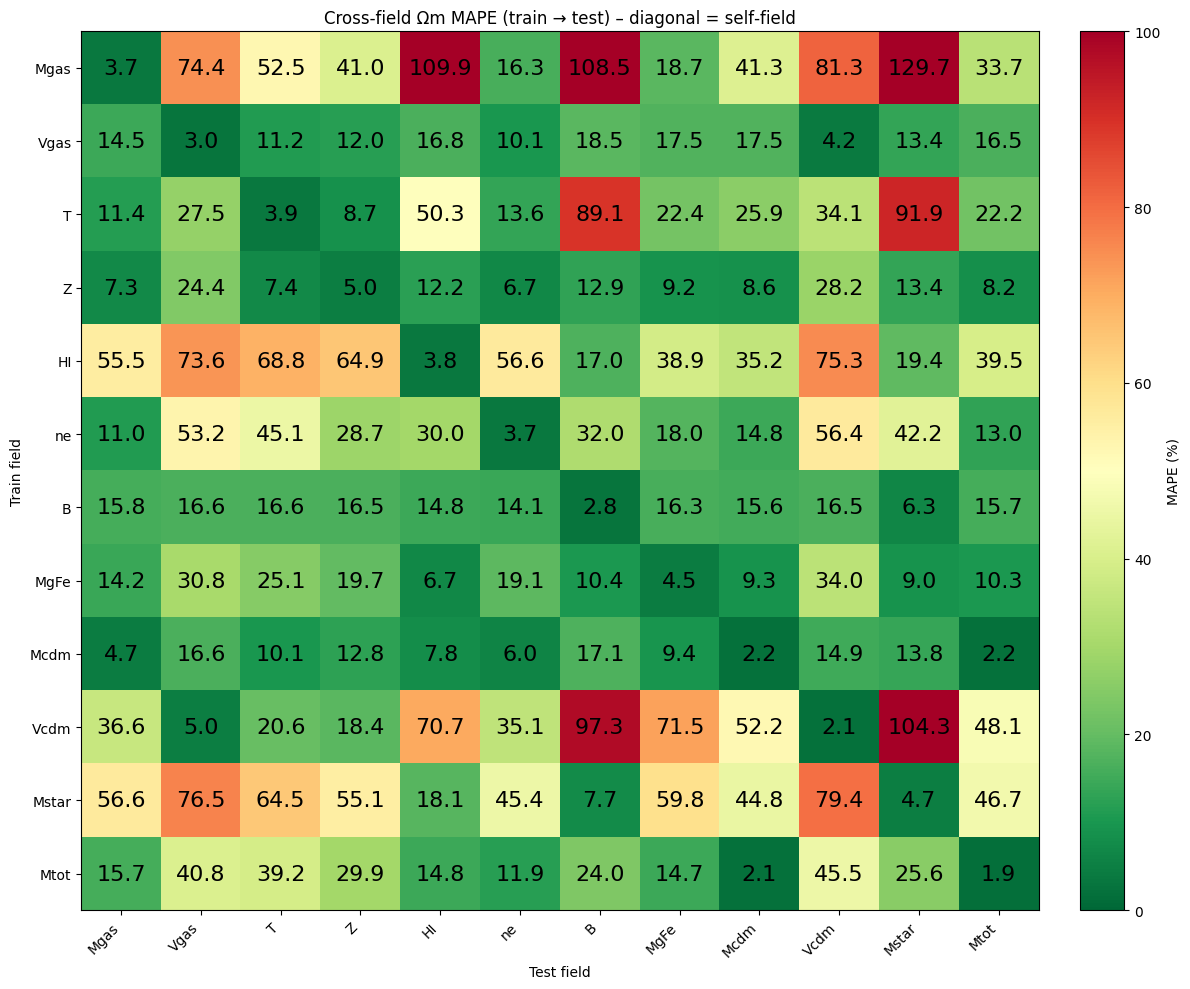

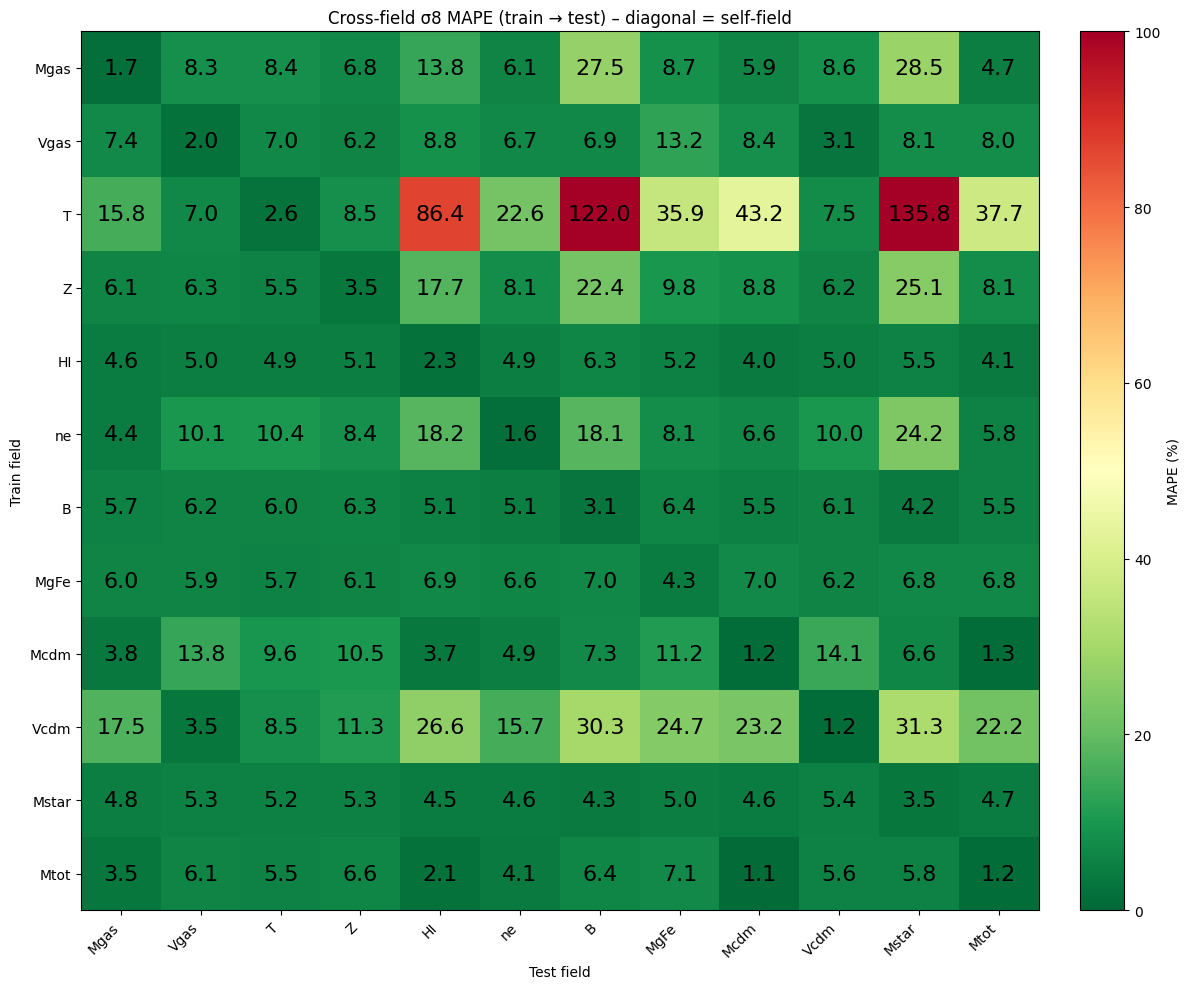

In [67]:
# Generating Ωm heatmap
plot_cross_heatmap(cross_df, 'Ωm_MAPE',
                   'Cross‑field Ωm MAPE (train → test) – diagonal = self‑field',
                   'crossfield_Om_MAPE_with_diag_manual.png')

# Generating σ8 heatmap
plot_cross_heatmap(cross_df, 'σ8_MAPE',
                   'Cross‑field σ8 MAPE (train → test) – diagonal = self‑field',
                   'crossfield_s8_MAPE_with_diag_manual.png')

## Cross Field Discussion


Interesting trends

Just a quick overview of the trends I spotted from eyeballing the heatmaps, will defintely go into more depth in the actual report, but here are the main things that are jumping out to me.

**Clustering of similar fields.**  

The fields that share physical units or describe related quantities tend to transfer well to each other, regardless of which is the training or test field. For example:
- The velocity maps, *Vcdm* and *Vgas* (both in km/s), show consistently low MAPE around 5% for both Ωm and σ8. Easy to see because its dark green. 
- Gas‑related fields like *Z* (metallicity) and *T* (temperature) have mutual transferability in the 7–9% range.
- Matter density fields, *Mcdm* and *Mtot* (both in units of \(h^{-1}M_\odot/(h^{-1}\mathrm{kpc})^2\)), exhibit both high generalisability and high predictability, with average errors around 2%.

**Asymmetrical relationships.**  

Very very interesting, curious to know why

Some field pairs show wildly different performance depending on which one is the training field. Example:
- Training on *Mgas* and testing on *B* gives an Ωm MAPE of 108.5%, but reversing the roles drops it to 15.8%.


# PLOTS SO FAR

Besides cross field heatmaps, in this section, I add plots for use in the report

In [68]:
# Computing unique true values once
y_true_orig = scaler.inverse_transform(y_test)
unique_true = np.unique(y_true_orig, axis=0)   # (4,2)
unique_om = unique_true[:,0]                  # true Ωm values
unique_s8 = unique_true[:,1]                  # true σ8 values

# Building a dictionary for quick MAPE lookup
mape_dict_Ωm = {r['field']: r['Ωm_MAPE'] for r in results_list}

fields = ['Mgas', 'Vgas', 'T', 'Z', 'HI', 'ne', 'B', 'MgFe', 'Mcdm', 'Vcdm', 'Mstar', 'Mtot']


## True vs Predicted minus True

### Ωm Plots

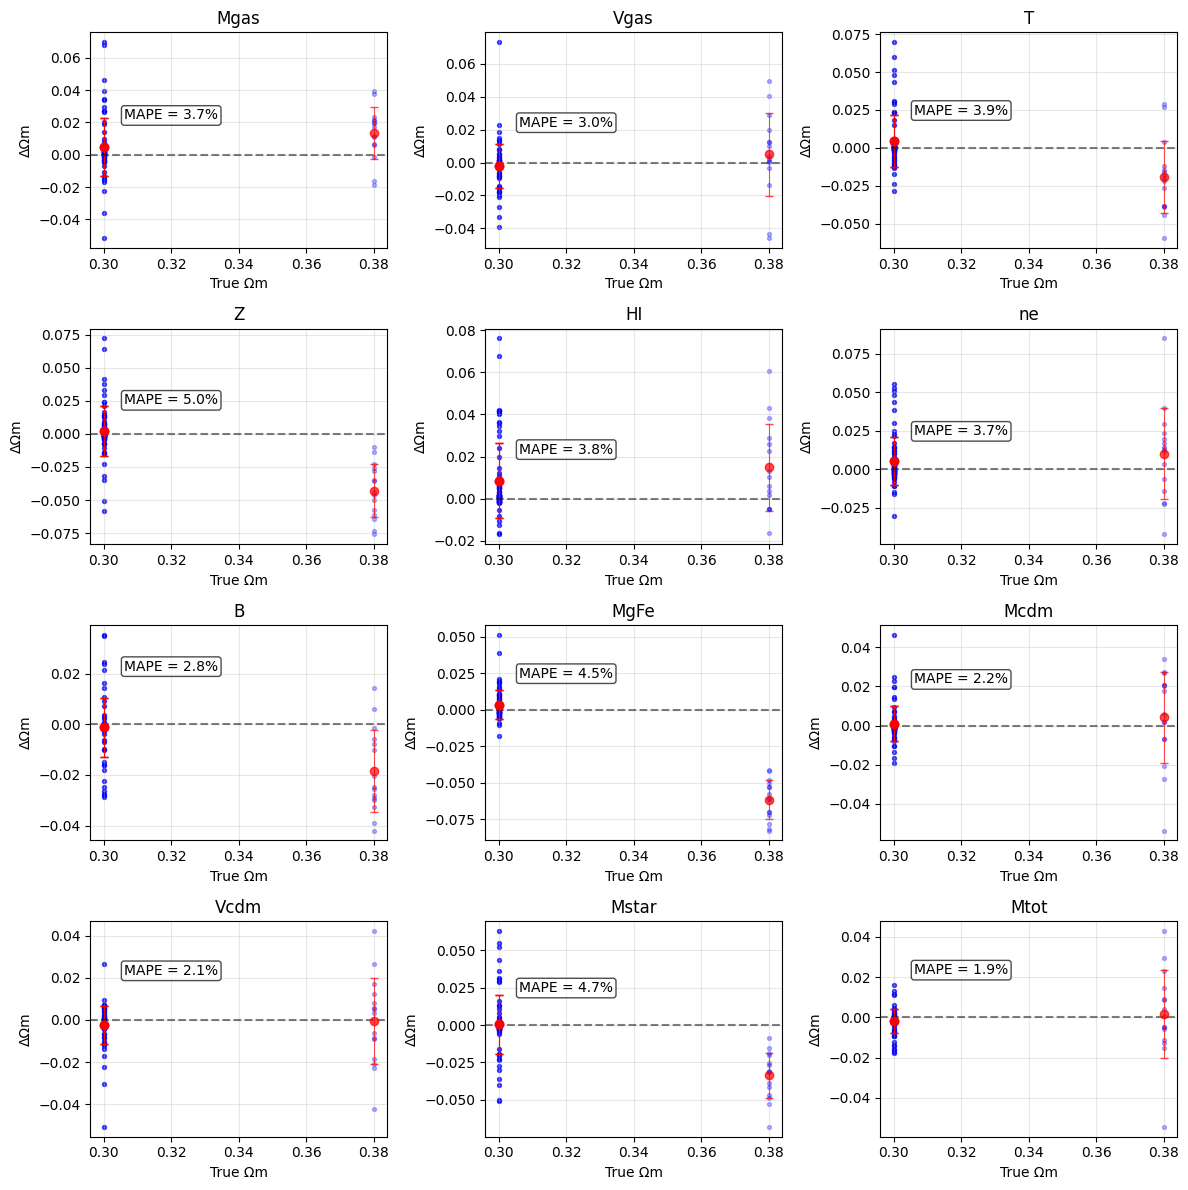

In [69]:
# Creating figure with 4 rows, 3 columns
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
axes = axes.flatten()

for idx, field in enumerate(fields):
    ax = axes[idx]

    # Loading model 
    model_path = f'single_field_model_{field}.keras'
    if not os.path.exists(model_path):
        ax.text(0.5, 0.5, 'Model missing', ha='center', va='center')
        ax.set_title(field)
        continue

    model = load_model(model_path)

    # Loading and preprocess field map
    fname = f'Maps_{field}_IllustrisTNG_1P_z=0.00.npy'
    full_path = os.path.join(data_folder, fname)
    arr = np.load(full_path).astype(np.float32)

    if field in ['Vgas', 'Vcdm']:
        X = arr
    else:
        X = np.log10(arr + 1e-5)

    X_train_raw = X[train_idx]
    mean_f = X_train_raw.mean(keepdims=True)
    std_f = X_train_raw.std(keepdims=True) + 1e-8
    X_norm = (X - mean_f) / std_f
    X_test_f = X_norm[test_idx, ..., np.newaxis]

    pred_scaled = model.predict(X_test_f, verbose=0)
    pred_orig = scaler.inverse_transform(pred_scaled)
    y_true_orig = scaler.inverse_transform(y_test)

    err_om = pred_orig[:,0] - y_true_orig[:,0]

    # Grouping errors by true Ωm
    groups = []
    for true_val in unique_om:
        mask = np.isclose(y_true_orig[:,0], true_val, atol=1e-5)
        groups.append(err_om[mask])

    # Computing means and stds
    means = [np.mean(g) for g in groups]
    stds  = [np.std(g) for g in groups]

    # Plotting individual points first (background)
    for i, true_val in enumerate(unique_om):
        ax.scatter([true_val]*len(groups[i]), groups[i],
                   alpha=0.3, s=8, color='blue', zorder=1)

    # Drawing error bars 
    ax.errorbar(unique_om, means, yerr=stds,
                fmt='o', color='red', capsize=3,
                linewidth=0.8, alpha=0.7, zorder=2)

    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('True Ωm')
    ax.set_ylabel('ΔΩm')
    ax.set_title(field)
    ax.grid(alpha=0.3)

    # Add MAPE annotation
    mape_val = mape_dict_Ωm.get(field, None)
    if mape_val is not None:
        x_center = np.mean(unique_om)   # centre of x‑axis (over the four true values)
        ax.text(x_center, 0.02, f'MAPE = {mape_val:.1f}%',
                ha='center', va='bottom', fontsize=10, color='black',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Turning off any unused subplots (should probably be none because im using all 12 fields)
for j in range(len(fields), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('all_fields_error_Om.png', dpi=150)
plt.show()

This gives me an overview of what I can discuss in the report for the single field perfomance, worst is Z at 5% MAPE, best is Mtot at 1.9% MAPE. Good results relative to the model paper

I mentioned the model paper results when I motivated B as a middle of pack field hence why I chose it as representantive 

Pasting here again for context


From Fig. 3 and Fig. 2 in the paper https://arxiv.org/abs/2109.09747v1

| Rank | Field | ⟨δΩm/Ωm⟩ |
|------|-------|-----------|
| 1 | Mdm | 2.9% |
| 2 | Mtot | 3.4% |
| 3 | HI | 4.2% |
| 4 | Mgas | 4.4% |
| 5 | ne | 5.0% |
| 6 | P | 5.3% |
| 6 | T | 5.3% |
| 8 | Vgas | 5.7% |
| **9** | **B** | **6.4%** |
| 10 | Vdm | 6.8% |
| 11 | Z | 8.8% |
| 12 | Mg/Fe | 11.4% |
| 13 | M★ | 19.8% |

Now checking σ8


### σ8 plot

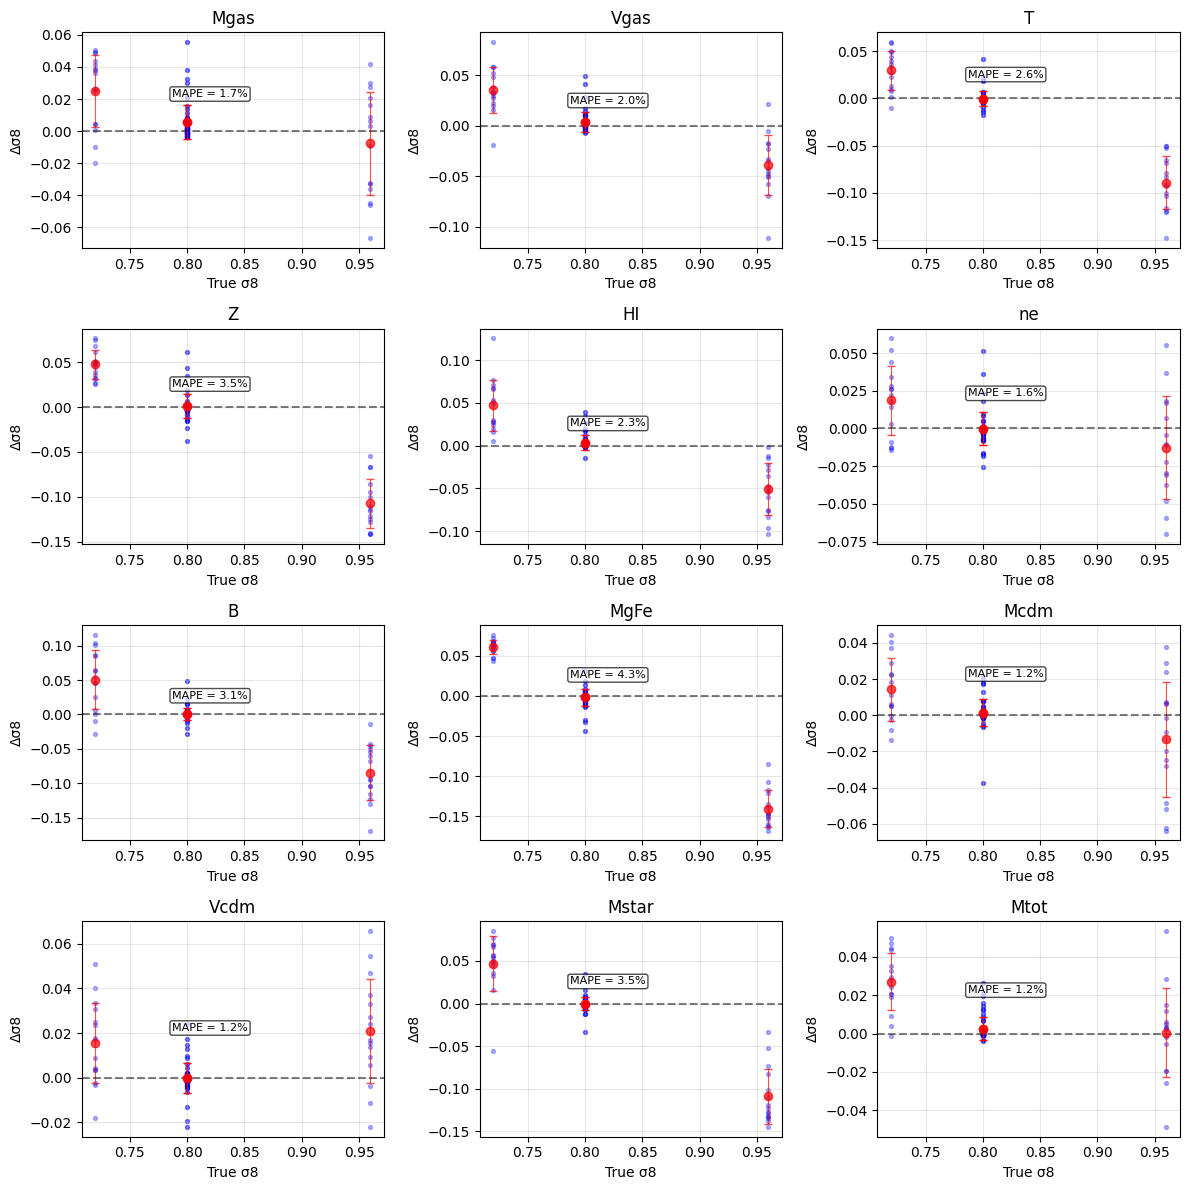

In [70]:
# Computing unique true values once
y_true_orig = scaler.inverse_transform(y_test)
unique_true = np.unique(y_true_orig, axis=0)   # (4,2)
unique_s8 = unique_true[:,1]                  # true σ8 values

# Building a dictionary for quick σ8 MAPE lookup
mape_dict_σ8 = {r['field']: r['σ8_MAPE'] for r in results_list}

# Creating figure with 4 rows, 3 columns
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
axes = axes.flatten()

for idx, field in enumerate(fields):
    ax = axes[idx]

    # Loading model 
    model_path = f'single_field_model_{field}.keras'
    if not os.path.exists(model_path):
        ax.text(0.5, 0.5, 'Model missing', ha='center', va='center')
        ax.set_title(field)
        continue

    model = load_model(model_path)

    # Loading and preprocessing field map
    fname = f'Maps_{field}_IllustrisTNG_1P_z=0.00.npy'
    full_path = os.path.join(data_folder, fname)
    arr = np.load(full_path).astype(np.float32)

    if field in ['Vgas', 'Vcdm']:
        X = arr
    else:
        X = np.log10(arr + 1e-5)

    X_train_raw = X[train_idx]
    mean_f = X_train_raw.mean(keepdims=True)
    std_f = X_train_raw.std(keepdims=True) + 1e-8
    X_norm = (X - mean_f) / std_f
    X_test_f = X_norm[test_idx, ..., np.newaxis]

    pred_scaled = model.predict(X_test_f, verbose=0)
    pred_orig = scaler.inverse_transform(pred_scaled)
    y_true_orig = scaler.inverse_transform(y_test)

    err_s8 = pred_orig[:,1] - y_true_orig[:,1]

    # Grouping errors by true σ8
    groups = []
    for true_val in unique_s8:
        mask = np.isclose(y_true_orig[:,1], true_val, atol=1e-5)
        groups.append(err_s8[mask])

    # Computing means and stds
    means = [np.mean(g) for g in groups]
    stds  = [np.std(g) for g in groups]

    # Plotting individual points first (background)
    for i, true_val in enumerate(unique_s8):
        ax.scatter([true_val]*len(groups[i]), groups[i],
                   alpha=0.3, s=8, color='blue', zorder=1)

    # Drawing error bars on top (foreground)
    ax.errorbar(unique_s8, means, yerr=stds,
                fmt='o', color='red', capsize=3,
                linewidth=0.8, alpha=0.7, zorder=2)

    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('True σ8')
    ax.set_ylabel('Δσ8')
    ax.set_title(field)
    ax.grid(alpha=0.3)

    # Adding MAPE annotation
    mape_val = mape_dict_σ8.get(field, None)
    if mape_val is not None:
        x_center = np.mean(unique_s8)   # centre of x‑axis (over the four true values)
        ax.text(x_center, 0.02, f'MAPE = {mape_val:.1f}%',
                ha='center', va='bottom', fontsize=8, color='black',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Turning off any unused subplots (again, should probably be none because im using all 12 fields)
for j in range(len(fields), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('all_fields_error_s8.png', dpi=150)
plt.show()

Similar trends as the Ωm, but error is smaller. 

### Loss Curves for all 12 Fields

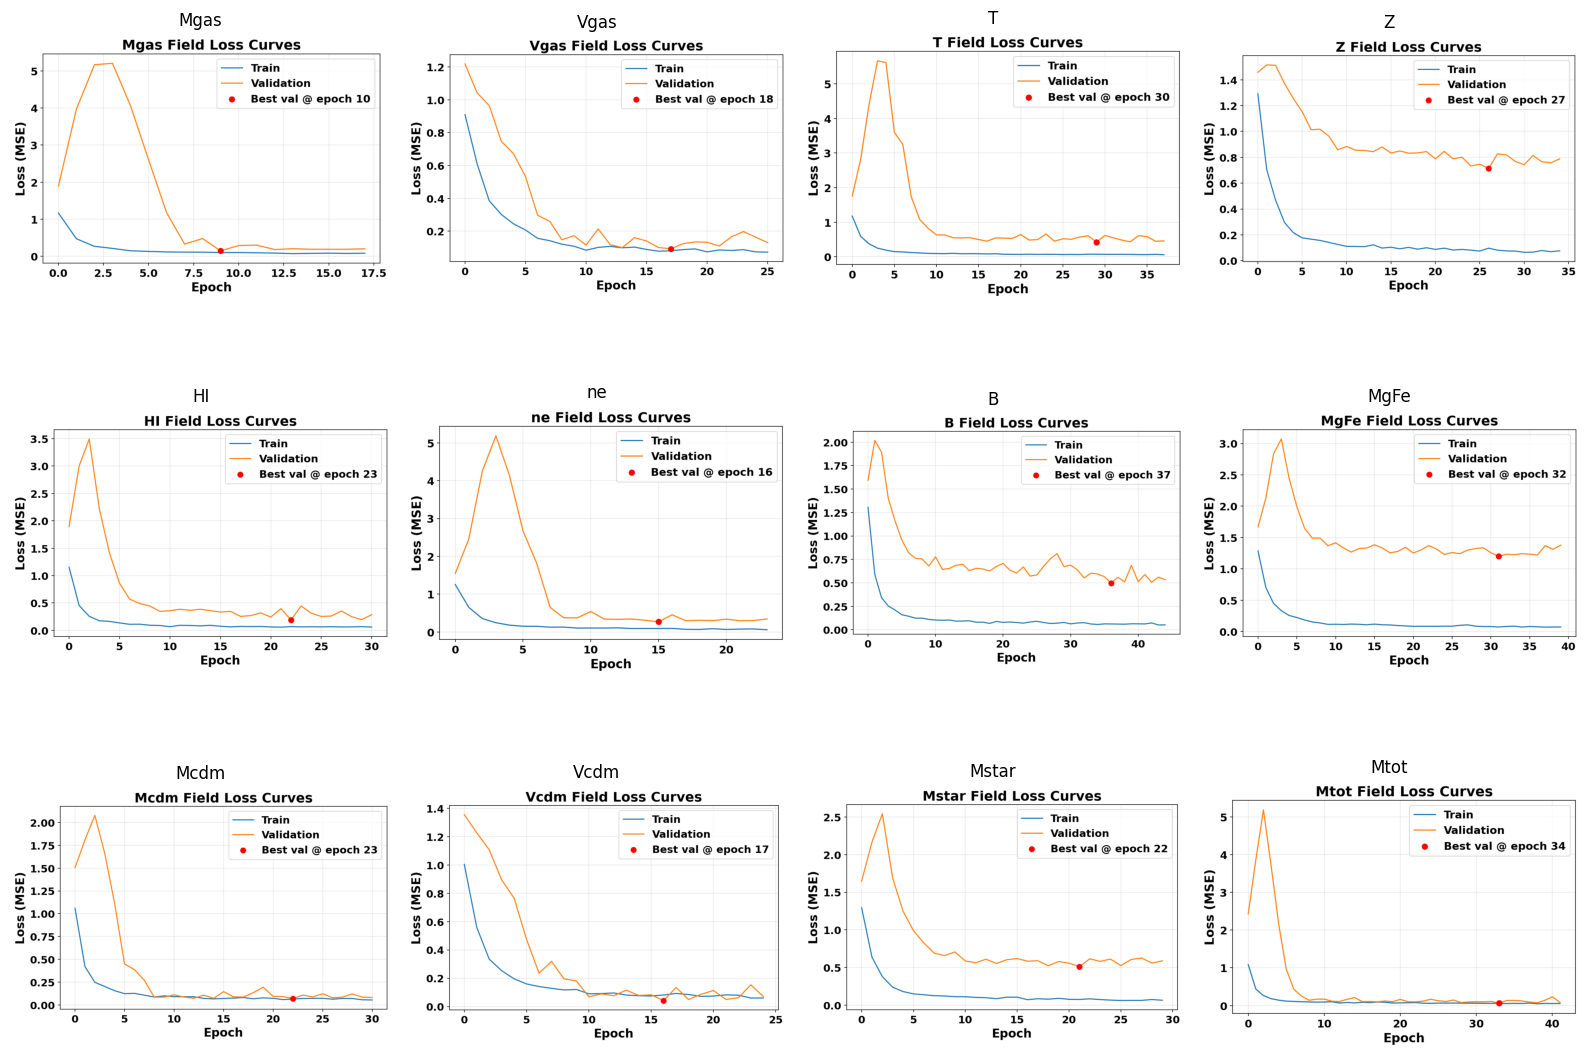

In [71]:
# I had saved them before so that comes in hany, just need to put them a grid for methodology in report
loss_dir = r"C:\Users\makan\ML Y3 PHYSICS\camels project\camels\multi_field_plots\loss"
fields = ['Mgas', 'Vgas', 'T', 'Z', 'HI', 'ne', 'B', 'MgFe', 'Mcdm', 'Vcdm', 'Mstar', 'Mtot']

# Creating a 3 rows, 4 columns grid
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()  # easier to index

for i, field in enumerate(fields):
    img_path = os.path.join(loss_dir, f"loss_{field}.png")
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')          # hide axes ticks
    axes[i].set_title(field, fontsize=12)

# Hiding any unused subplots (just in case)
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Interesting, overall no signs of severe overfitting or underfitting but Z, MgFe, B and Mstar have the worst loss curves ie training and val never meet. Will definitely be evident in perfomance metrics graphs 

## BEST SINGLE FIELD VS MULTI FIELD

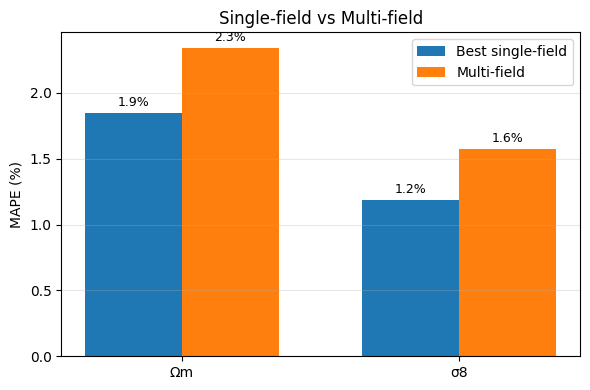

In [74]:
# Loading  multi‑field results 
df_multi = pd.read_csv('multi_model_comparison.csv')
# Finding the row for the best multi‑field model 
best_multi = df_multi.sort_values('Ωm_MAPE').iloc[0]  

# Best single‑field (from earlier)
best_single = df_sorted.iloc[0]   # best by Ωm MAPE

# Preparing data
params = ['Ωm', 'σ8']
single_mape = [best_single['Ωm_MAPE'], best_single['σ8_MAPE']]
multi_mape  = [best_multi['Ωm_MAPE'], best_multi['σ8_MAPE']]

x = np.arange(len(params))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, single_mape, width, label='Best single‑field')
bars2 = ax.bar(x + width/2, multi_mape, width, label='Multi‑field')

# Adding value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

ax.set_ylabel('MAPE (%)')
ax.set_xticks(x)
ax.set_xticklabels(params)
ax.set_title('Single‑field vs Multi‑field')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('multi_vs_best_single.png', dpi=150)
plt.show()

As discussed

### MAPE BAR CHARTS

Trying more informative ones

C:\Users\makan\AppData\Local\Temp\ipykernel_4616\1322897132.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(fields_om, rotation=45, ha='right')


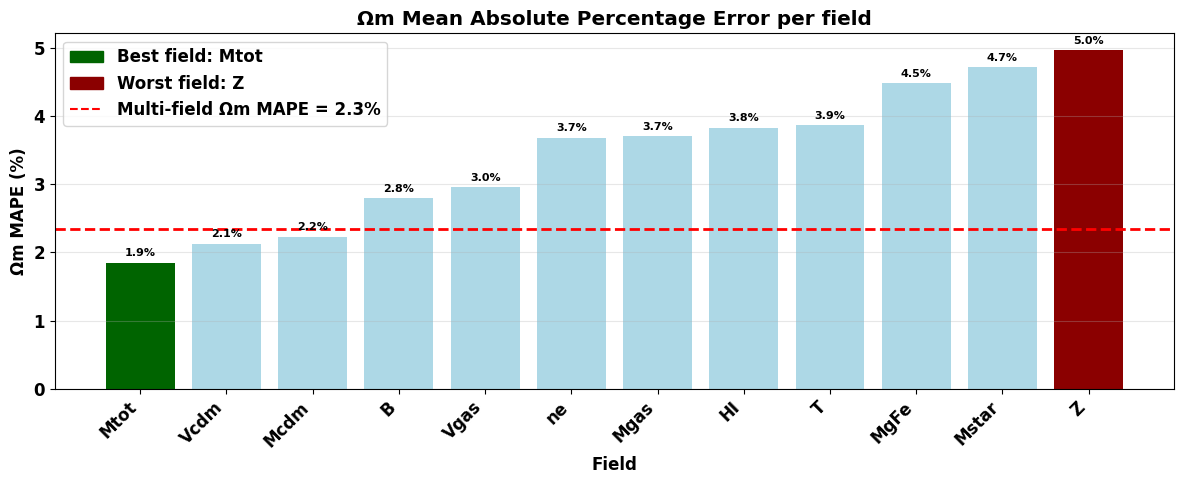

In [77]:
# Loading results
df_single = pd.read_csv('single_field_results.csv')
df_multi = pd.read_csv('multi_model_comparison.csv')

# Best multi‑field MAPE for Ωm
multi_om = df_multi['Ωm_MAPE'].min()

# Sorting by Ωm MAPE
df_om = df_single.sort_values('Ωm_MAPE').reset_index(drop=True)
fields_om = df_om['field']
best_field_om = fields_om.iloc[0]
worst_field_om = fields_om.iloc[-1]

# Bar colours
def get_bar_color_om(field):
    if field == best_field_om:
        return 'darkgreen'
    elif field == worst_field_om:
        return 'darkred'
    else:
        return 'lightblue'

# Plotting
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(fields_om, df_om['Ωm_MAPE'], color=[get_bar_color_om(f) for f in fields_om])
ax.axhline(y=multi_om, color='red', linestyle='--', linewidth=2,
           label=f'Multi‑field Ωm MAPE = {multi_om:.1f}%')
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Ωm MAPE (%)')
ax.set_xlabel('Field')
ax.set_title('Ωm Mean Absolute Percentage Error per field')
ax.set_xticklabels(fields_om, rotation=45, ha='right')
best_patch = plt.Rectangle((0,0),1,1, color='darkgreen', label=f'Best field: {best_field_om}')
worst_patch = plt.Rectangle((0,0),1,1, color='darkred', label=f'Worst field: {worst_field_om}')
ax.legend(handles=[best_patch, worst_patch, plt.Line2D([0],[0], color='red', linestyle='--', label=f'Multi‑field Ωm MAPE = {multi_om:.1f}%')])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('MAPE_Om_bar_chart.png', dpi=150)
plt.show()

C:\Users\makan\AppData\Local\Temp\ipykernel_4616\1555857439.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(fields_s8, rotation=45, ha='right')


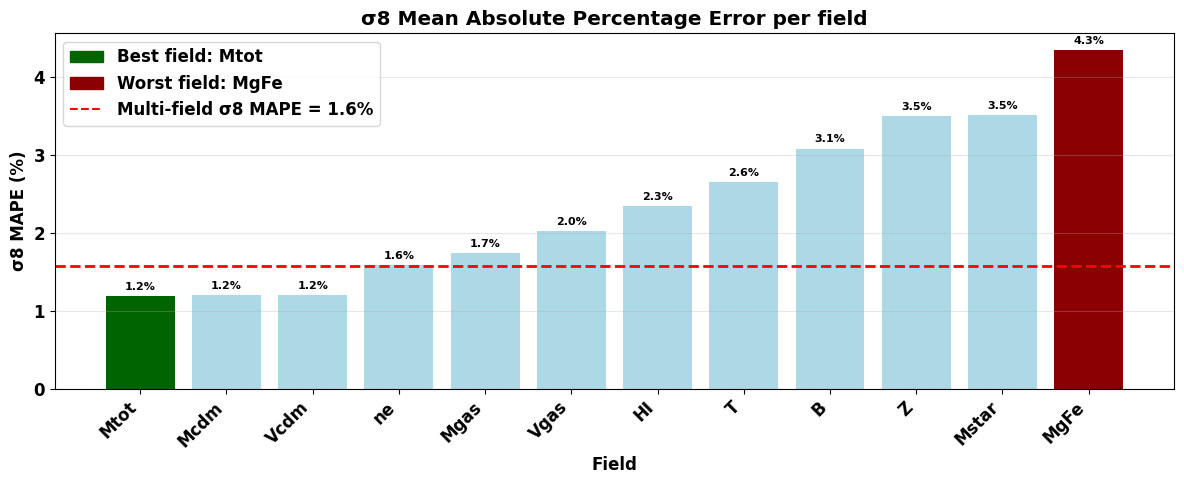

In [78]:
# Loading results
df_single = pd.read_csv('single_field_results.csv')
df_multi = pd.read_csv('multi_model_comparison.csv')

# Best multi‑field MAPE for σ8
multi_s8 = df_multi['σ8_MAPE'].min()

# Sorting by σ8 MAPE
df_s8 = df_single.sort_values('σ8_MAPE').reset_index(drop=True)
fields_s8 = df_s8['field']
best_field_s8 = fields_s8.iloc[0]
worst_field_s8 = fields_s8.iloc[-1]

# Bar colours
def get_bar_color_s8(field):
    if field == best_field_s8:
        return 'darkgreen'
    elif field == worst_field_s8:
        return 'darkred'
    else:
        return 'lightblue'

# Plotting
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(fields_s8, df_s8['σ8_MAPE'], color=[get_bar_color_s8(f) for f in fields_s8])
ax.axhline(y=multi_s8, color='red', linestyle='--', linewidth=2,
           label=f'Multi‑field σ8 MAPE = {multi_s8:.1f}%')
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
ax.set_ylabel('σ8 MAPE (%)')
ax.set_xlabel('Field')
ax.set_title('σ8 Mean Absolute Percentage Error per field')
ax.set_xticklabels(fields_s8, rotation=45, ha='right')
best_patch = plt.Rectangle((0,0),1,1, color='darkgreen', label=f'Best field: {best_field_s8}')
worst_patch = plt.Rectangle((0,0),1,1, color='darkred', label=f'Worst field: {worst_field_s8}')
ax.legend(handles=[best_patch, worst_patch, plt.Line2D([0],[0], color='red', linestyle='--', label=f'Multi‑field σ8 MAPE = {multi_s8:.1f}%')])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('MAPE_s8_bar_chart.png', dpi=150)
plt.show()

## Ease of predictability vs generalisability Plots


I think this is the most interesting part of the project!


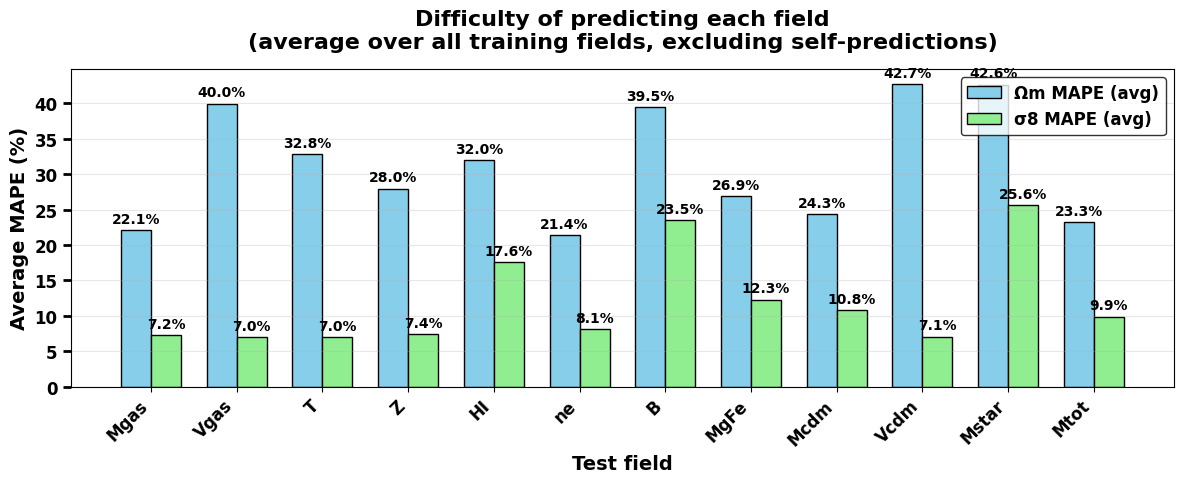

In [7]:
# Loading the CSV
df = pd.read_csv(r'C:\Users\makan\ML Y3 PHYSICS\camels project\camels\extension 2\cross_field_results_with_diag.csv')

# List of fields in the desired order (same as before)
fields = ['Mgas', 'Vgas', 'T', 'Z', 'HI', 'ne', 'B', 'MgFe', 'Mcdm', 'Vcdm', 'Mstar', 'Mtot']

# Excluding diagonal (self‑predictions)
df_offdiag = df[df['train_field'] != df['test_field']]

# Computing average MAPE for each test field (Ωm and σ8)
test_avg_om = df_offdiag.groupby('test_field')['Ωm_MAPE'].mean()
test_avg_s8 = df_offdiag.groupby('test_field')['σ8_MAPE'].mean()

# Reordering to match the fields list
test_avg_om = test_avg_om.reindex(fields)
test_avg_s8 = test_avg_s8.reindex(fields)

# Setting up the plot
plt.rcParams.update({'font.size': 12, 'font.weight': 'bold'})
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.title_fontsize'] = 12

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(fields))
width = 0.35

bars1 = ax.bar(x - width/2, test_avg_om, width, label='Ωm MAPE (avg)', color='skyblue', edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, test_avg_s8, width, label='σ8 MAPE (avg)', color='lightgreen', edgecolor='black', linewidth=1)

# Adding value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(fields, rotation=45, ha='right', fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelsize=12, width=2, length=6, which='major')

ax.set_ylabel('Average MAPE (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Test field', fontsize=14, fontweight='bold')
ax.set_title('Difficulty of predicting each field\n(average over all training fields, excluding self‑predictions)',
             fontsize=16, fontweight='bold', pad=15)
ax.legend(frameon=True, edgecolor='black', fontsize=12, loc='best')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('test_field_difficulty.png', dpi=150)
plt.show()


## Ease of predictability Commentary

Again, σ8 outperfoms Ωm by a wide margin. 

Just a few quick observations from the bar chart showing average MAPE when each field is used as the **test** field ( how easy each field is to predict, averaged over all training fields):

- **Matter density fields** (*Mcdm*, *Mtot*) and **electron density** (*ne*) stand out as the easiest to predict for both Ωm and σ8, not surprise given they have a  strong cosmological signal.

- ***Mgas* is relatively easy to predict**, will need to see if this carries over to generalisability

- **Velocity fields** (*Vgas*, *Vcdm*) and ***B* are among the hardest to predict**, 
- ***Mstar* and *Vcdm* are particularly difficult test fields for Ωm**, with average MAPEs well above 40%, while for σ8 the spread is narrower overall.



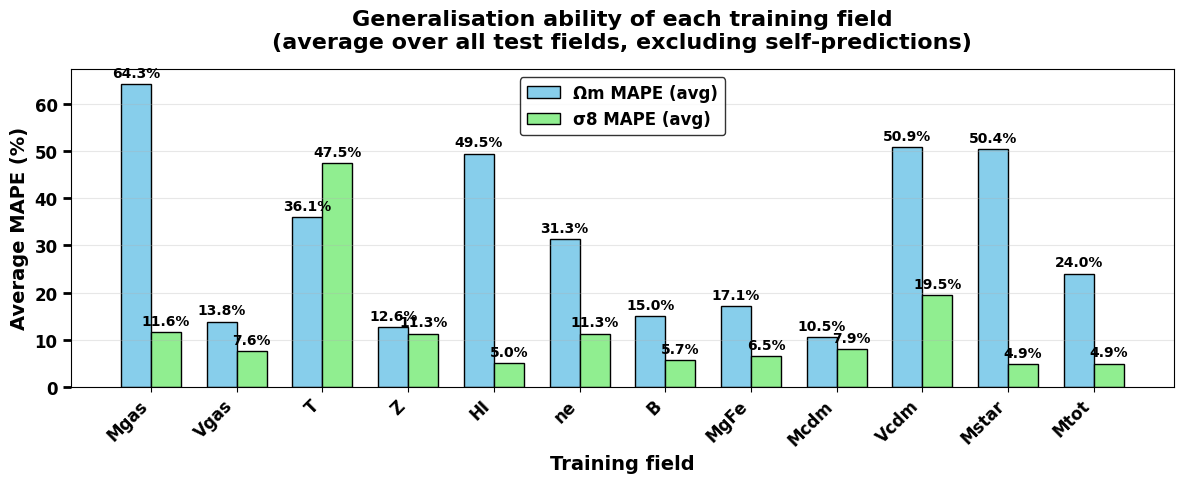

In [8]:
# Loading the CSV
df = pd.read_csv(r'C:\Users\makan\ML Y3 PHYSICS\camels project\camels\extension 2\cross_field_results_with_diag.csv')

# Listing of fields in the desired order (same as before)
fields = ['Mgas', 'Vgas', 'T', 'Z', 'HI', 'ne', 'B', 'MgFe', 'Mcdm', 'Vcdm', 'Mstar', 'Mtot']

# Excluding diagonal (self‑predictions)
df_offdiag = df[df['train_field'] != df['test_field']]

# Computing average MAPE for each train field (Ωm and σ8)
train_avg_om = df_offdiag.groupby('train_field')['Ωm_MAPE'].mean()
train_avg_s8 = df_offdiag.groupby('train_field')['σ8_MAPE'].mean()

# Reordering to match the fields list
train_avg_om = train_avg_om.reindex(fields)
train_avg_s8 = train_avg_s8.reindex(fields)

# Setting up the plot
plt.rcParams.update({'font.size': 12, 'font.weight': 'bold'})
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.title_fontsize'] = 12

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(fields))
width = 0.35

bars1 = ax.bar(x - width/2, train_avg_om, width, label='Ωm MAPE (avg)', color='skyblue', edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, train_avg_s8, width, label='σ8 MAPE (avg)', color='lightgreen', edgecolor='black', linewidth=1)

# Adding value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(fields, rotation=45, ha='right', fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelsize=12, width=2, length=6, which='major')

ax.set_ylabel('Average MAPE (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Training field', fontsize=14, fontweight='bold')
ax.set_title('Generalisation ability of each training field\n(average over all test fields, excluding self‑predictions)',
             fontsize=16, fontweight='bold', pad=15)

ax.legend(frameon=True, edgecolor='black', fontsize=12, loc='best')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('train_field_generalisation.png', dpi=150)
plt.show()

### Generalisability Commentary

Again, σ8 shows better generalisability than Ωm across nearly all fields.

Quick takeaways from the bar chart showing average MAPE when each field is used as the **training** field (averaged over all test fields):

- ***Mcdm*, *Z*, *Vgas*, are strong  generalisers** for Ωm, so they train models that transfer well to other fields. Interesting. 

- ***Mgas* is a notably poor generaliser** for Ωm despite being relatively easy to predict; the model trained on it simply doesn't transfer.

- ***Mstar* and *Vcdm* generalise very poorly for Ωm**, with average training MAPEs above 50%.

- For σ8, the spread is much tighter, again its more generalisable across all fields, and **HI and *Mstar* are surprisingly good generalisers** despite  a horrible perfomance with Ωm

- ***T* is a disastrous generaliser for σ8** (~47% train MAPE) even though it was easy to predict



# Extension 2

## Clustered Multi-field

How much information do I really need for the multifield dataset?

If I remove some fields, do I still have relatively good information for inference?

I motivated this up top

Four subsets:
- Density fields (Mcdm, Mtot, ne, HI)
- Gas fields (Z, Mgas, T, Vgas)
- Velocity fields (Vgas, Vcdm)
- A mixed subset (Mcdm, Z, Vgas)

In [31]:
# Mapping from field name to channel index (order in X_log_mmap)
field_to_channel = {
    'Mgas': 0, 'Vgas': 1, 'T': 2, 'Z': 3, 'HI': 4, 'ne': 5,
    'B': 6, 'MgFe': 7, 'Mcdm': 8, 'Vcdm': 9, 'Mstar': 10, 'Mtot': 11
}

subsets = [
    # Density fields
    ['Mcdm', 'Mtot', 'ne', 'HI'],
    # Gas fields
    ['Z', 'Mgas', 'T', 'Vgas'],
    # Velocity
    ['Vgas', 'Vcdm'],
    # Mixed
    ['Mcdm', 'Z', 'Vgas'],

]
# Full 12‑field baseline 
# No wait its actually 2.3 and 1.6, i corrected in the plotting cell below. Cant rerun this cell due to time constraints
baseline_om_mape = 3.2   # from my earlier multi‑field result
baseline_s8_mape = 1.6

def build_subset_model(input_shape, num_outputs=2, base_filters=2, dense_units=120, dropout=0.3):
    """Same architecture as before, but with variable input channels."""
    inputs = keras.Input(shape=input_shape)
    x = inputs
    
    # Block 1
    x = layers.Conv2D(base_filters, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    # Block 2
    x = layers.Conv2D(base_filters*2, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    # Block 3
    x = layers.Conv2D(base_filters*4, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    # Block 4
    x = layers.Conv2D(base_filters*8, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    # Block 5
    x = layers.Conv2D(base_filters*16, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    # Block 6
    x = layers.Conv2D(base_filters*32, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    # Final projection
    x = layers.Conv2D(base_filters*64, 4, strides=1, padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    # Dense head
    x = layers.Flatten()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_outputs)(x)
    
    model = keras.Model(inputs, outputs)
    return model

def train_and_evaluate_subset(subset_fields, channels):
    """Training a model on the given subset of channels and return test MAPE."""
    # Select the channels
    mean_sub = mean[..., channels]      # shape (1,1,1, n_channels)
    std_sub = std[..., channels]        # shape (1,1,1, n_channels)
    
    # Building the training and validation arrays (in memory, manageable for small subsets)
    X_train_sub = (X_log_mmap[train_idx][..., channels] - mean_sub) / std_sub
    X_val_sub   = (X_log_mmap[val_idx][..., channels] - mean_sub) / std_sub
    X_test_sub  = (X_log_mmap[test_idx][..., channels] - mean_sub) / std_sub
    
    # Building and compile model
    model = build_subset_model(input_shape=(256,256,len(channels)))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse', metrics=['mae'])
    
    # Early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    
    # Training
    history = model.fit(
        X_train_sub, y_train,
        validation_data=(X_val_sub, y_val),
        epochs=50,
        batch_size=16,
        sample_weight=sample_weights_train,
        callbacks=[early_stop],
        verbose=1
    )
    
    # Predicting on test set
    y_pred_scaled = model.predict(X_test_sub, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test)
    
    # Computing MAPE
    mape_om = np.mean(np.abs((y_pred[:,0] - y_true[:,0]) / y_true[:,0])) * 100
    mape_s8 = np.mean(np.abs((y_pred[:,1] - y_true[:,1]) / y_true[:,1])) * 100
    
    return mape_om, mape_s8

# Running experiments
results = {}
for subset in subsets:
    channels = [field_to_channel[f] for f in subset]
    print(f"\n===== Training on subset: {subset} =====")
    om_mape, s8_mape = train_and_evaluate_subset(subset, channels)
    results[tuple(subset)] = (om_mape, s8_mape)
    print(f"Ωm MAPE: {om_mape:.1f}%, σ8 MAPE: {s8_mape:.1f}%")

# Print comparison, just to keep track
print("\n===== Summary =====")
print(f"Full 12‑field baseline: Ωm MAPE = {baseline_om_mape:.1f}%, σ8 MAPE = {baseline_s8_mape:.1f}%")
for subset, (om, s8) in results.items():
    print(f"Subset {subset}: Ωm MAPE = {om:.1f}%, σ8 MAPE = {s8:.1f}%")


===== Training on subset: ['Mcdm', 'Mtot', 'ne', 'HI'] =====


C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - loss: 1.5227 - mae: 0.8471 - val_loss: 1.5403 - val_mae: 0.5828
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.6063 - mae: 0.5635 - val_loss: 1.9771 - val_mae: 0.9452
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.3072 - mae: 0.3997 - val_loss: 2.2215 - val_mae: 1.1023
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.2190 - mae: 0.3438 - val_loss: 2.0465 - val_mae: 1.0681
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.1356 - mae: 0.2638 - val_loss: 1.3647 - val_mae: 0.8091
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.1326 - mae: 0.2522 - val_loss: 0.8305 - val_mae: 0.5522
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.1109 - mae: 0.2096 - val_loss: 0.5412 - val_mae: 0.3772
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.1143 - mae: 0.2095 - val_loss: 0.4873 - val_mae: 0.3307
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.08

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - loss: 1.4135 - mae: 0.8404 - val_loss: 1.2050 - val_mae: 0.4840
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.5837 - mae: 0.5282 - val_loss: 2.0195 - val_mae: 0.8744
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.2726 - mae: 0.3680 - val_loss: 2.7506 - val_mae: 1.1867
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.1983 - mae: 0.3200 - val_loss: 1.9955 - val_mae: 1.0014
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.1316 - mae: 0.2594 - val_loss: 1.4244 - val_mae: 0.7962
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.1230 - mae: 0.2354 - val_loss: 0.8898 - val_mae: 0.5718
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.1161 - mae: 0.2140 - val_loss: 0.4504 - val_mae: 0.3542
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.1032 - mae: 0.2028 - val_loss: 0.3889 - val_mae: 0.3265
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.08

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - loss: 1.2539 - mae: 0.7581 - val_loss: 2.1684 - val_mae: 0.9397
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.5300 - mae: 0.5005 - val_loss: 3.6074 - val_mae: 1.3105
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.3485 - mae: 0.4183 - val_loss: 3.8651 - val_mae: 1.3762
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.2759 - mae: 0.3692 - val_loss: 3.5709 - val_mae: 1.3580
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.1850 - mae: 0.3004 - val_loss: 2.2707 - val_mae: 1.0743
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.1640 - mae: 0.2774 - val_loss: 1.2554 - val_mae: 0.7591
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.1310 - mae: 0.2403 - val_loss: 0.7742 - val_mae: 0.5042
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.1310 - mae: 0.2266 - val_loss: 0.4879 - val_mae: 0.3777
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.10

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - loss: 1.3895 - mae: 0.8267 - val_loss: 2.0027 - val_mae: 0.8382
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.5626 - mae: 0.5398 - val_loss: 3.2958 - val_mae: 1.1937
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.2910 - mae: 0.3995 - val_loss: 3.8759 - val_mae: 1.4172
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.2410 - mae: 0.3639 - val_loss: 2.7069 - val_mae: 1.1791
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.1773 - mae: 0.3032 - val_loss: 1.6630 - val_mae: 0.8788
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.1651 - mae: 0.2824 - val_loss: 1.1793 - val_mae: 0.7057
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.1348 - mae: 0.2509 - val_loss: 0.7664 - val_mae: 0.5021
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.1219 - mae: 0.2274 - val_loss: 0.4110 - val_mae: 0.3459
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.13

### Plotting on a bar chart : Subsets vs Full

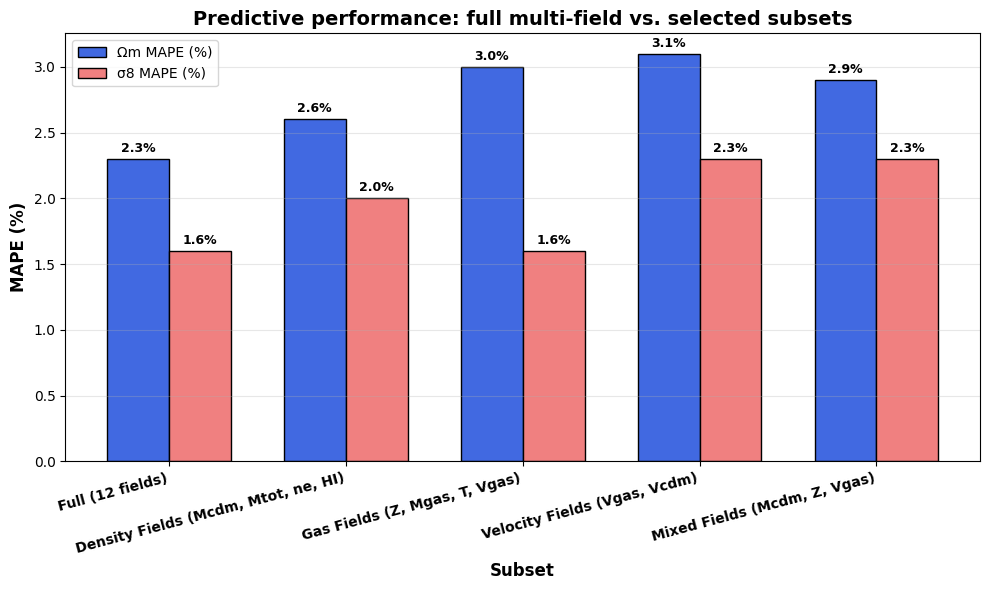

In [34]:
# Data
models = [
    "Full (12 fields)",
    "Density Fields (Mcdm, Mtot, ne, HI)",
    "Gas Fields (Z, Mgas, T, Vgas)",
    "Velocity Fields (Vgas, Vcdm)",
    "Mixed Fields (Mcdm, Z, Vgas)"
]
om_mape = [2.3, 2.6, 3.0, 3.1, 2.9] # corrected the baseline metrics
s8_mape = [1.6, 2.0, 1.6, 2.3, 2.3]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, om_mape, width, label='Ωm MAPE (%)', color='royalblue', edgecolor='black')
bars2 = ax.bar(x + width/2, s8_mape, width, label='σ8 MAPE (%)', color='lightcoral', edgecolor='black')

# Adding value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
# Plotting

ax.set_ylabel('MAPE (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Subset', fontsize=12, fontweight='bold')
ax.set_title('Predictive performance: full multi‑field vs. selected subsets', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=10, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('subset_comparison.png', dpi=150)
plt.show()

No subset beats the full model. Interesting

# End of Notebook

In this notebook, for the multi‑field problem , I  stacked all 12 channels and trained a model using the single‑field tuned architecture as a baseline. 

I then trained all twelve single‑field models under identical settings to establish a fair comparison, evaluated cross‑field generalisability, and finally explored how much information is really needed by testing smaller subsets of fields.




## Extra struff - not submitted